# © 2025 Maria Westrin. All rights reserved.
# This notebook and its outputs are provided for portfolio demonstration.


In [7]:
# Cell 0 — Local Windows paths (FIX)
from pathlib import Path

DATA_PATH = Path(r"C:\Users\maria\Downloads\financial_raw_data.csv")
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

OUTPUT_DIR = Path(r"C:\Users\maria\Downloads\financial_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ DATA_PATH:", DATA_PATH)
print("✓ OUTPUT_DIR:", OUTPUT_DIR)


✓ DATA_PATH: C:\Users\maria\Downloads\financial_raw_data.csv
✓ OUTPUT_DIR: C:\Users\maria\Downloads\financial_outputs


In [8]:
# Cell 1 — Imports + aristocratic palette
from __future__ import annotations

import json
import math
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PALETTE = {
    "navy": "#0B1D39",
    "burgundy": "#5A1A1A",
    "gold": "#C9A227",
    "forest": "#1D3B2A",
    "ivory": "#F7F2E7",
    "slate": "#3A4750",
    "plum": "#4B2E83",
}

ARISTO_CYCLE = [PALETTE["navy"], PALETTE["burgundy"], PALETTE["forest"], PALETTE["plum"], PALETTE["gold"], PALETTE["slate"]]

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.facecolor": PALETTE["ivory"],
    "axes.facecolor": PALETTE["ivory"],
    "axes.edgecolor": PALETTE["slate"],
    "axes.labelcolor": PALETTE["navy"],
    "xtick.color": PALETTE["navy"],
    "ytick.color": PALETTE["navy"],
    "text.color": PALETTE["navy"],
    "grid.color": PALETTE["slate"],
    "grid.alpha": 0.18,
    "axes.grid": True,
    "axes.prop_cycle": plt.cycler(color=ARISTO_CYCLE),
})

ARISTO_CMAP = LinearSegmentedColormap.from_list(
    "aristo",
    [PALETTE["navy"], PALETTE["plum"], PALETTE["ivory"], PALETTE["gold"], PALETTE["burgundy"]],
    N=256
)

print("✓ Environment ready")


✓ Environment ready


In [9]:
# Cell 2 — Load dataset
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
df.head()


Shape: 5,000 rows × 32 cols


,transaction_id,date,timestamp,company_name,ticker_symbol,sector,country,currency,transaction_type,price_per_share,...,spread_pct,portfolio_type,risk_rating,analyst_rating,esg_score,credit_rating,var_95,liquidity_score,quarter,fiscal_year
0,TXN100001,2020-01-01,2020-01-01 14:26:07,Essity,ESSI,Consumer Staples,Sweden,SEK,DIVIDEND,193414.47,...,0.0110,GROWTH,LOW,BUY,58.1,A,5739438.34,5.0,Q1,2020
1,TXN100002,2020-01-02,2020-01-02 12:28:19,Electrolux,ELEC,Consumer Discretionary,Sweden,SEK,BUY,78853.37,...,0.0140,MIXED,VERY_HIGH,SELL,58.6,AA-,20162749.47,6.5,Q1,2020
2,TXN100003,2020-01-02,2020-01-02 10:05:10,Essity,ESSI,Consumer Staples,Sweden,SEK,SPLIT,99570.72,...,0.0047,MIXED,VERY_HIGH,STRONG_BUY,32.9,A,5249510.56,8.8,Q1,2020
3,TXN100004,2020-01-03,2020-01-03 09:13:53,Spotify,SPOT,Technology,Sweden,SEK,BUY,614230.80,...,0.0174,VALUE,HIGH,HOLD,70.5,A,88784257.09,3.4,Q1,2020
4,TXN100005,2020-01-03,2020-01-03 10:45:15,IKEA Holding,IKEA,Consumer Discretionary,Netherlands,EUR,DIVIDEND,142286.33,...,0.0030,FIXED_INCOME,MEDIUM,STRONG_BUY,32.0,BBB+,24988927.86,9.4,Q1,2020


In [10]:
# Cell 3 — Normalize types
df = df.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

for col in ["company_name","ticker_symbol","sector","country","currency","transaction_type"]:
    df[col] = df[col].astype(str).str.strip()

df["ticker_symbol"] = df["ticker_symbol"].str.upper()
df["transaction_type_clean"] = df["transaction_type"].str.upper().str.strip()

num_cols = [
    "price_per_share","volume","transaction_value","market_cap_msek","pe_ratio",
    "earnings_msek","revenue_msek","debt_to_equity","return_on_equity","dividend_yield",
    "beta","sharpe_ratio","daily_return","spread_pct","esg_score","var_95","liquidity_score",
    "fiscal_year"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

assert df["date"].notna().all(), "Date parsing failed for some rows."
assert df["timestamp"].notna().all(), "Timestamp parsing failed for some rows."

print("✓ Types normalized")
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())


✓ Types normalized
Date range: 2020-01-01 → 2024-12-31


Duplicate rows: 0
Duplicate transaction_id: 0
Mismatches (>1%): 0.000%


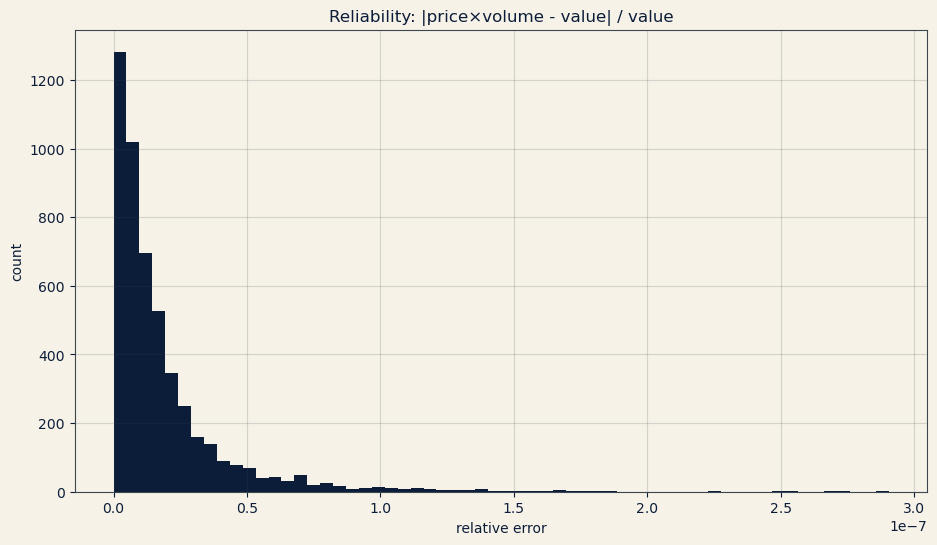

In [11]:
# Cell 4 — Integrity checks
dup_rows = int(df.duplicated().sum())
dup_ids  = int(df["transaction_id"].duplicated().sum())

print("Duplicate rows:", dup_rows)
print("Duplicate transaction_id:", dup_ids)

assert dup_rows == 0, "Duplicate rows detected."
assert dup_ids == 0, "Duplicate transaction_id detected."

calc_value = df["price_per_share"] * df["volume"]
den = df["transaction_value"].replace(0, np.nan)
df["value_diff_pct"] = (calc_value - df["transaction_value"]).abs() / den

mismatch_rate = float((df["value_diff_pct"] > 0.01).mean())  # >1%
print(f"Mismatches (>1%): {mismatch_rate*100:.3f}%")
assert mismatch_rate < 0.01, "Too many mismatches in transaction_value vs price×volume."

plt.figure()
plt.hist(df["value_diff_pct"].dropna(), bins=60)
plt.title("Reliability: |price×volume - value| / value")
plt.xlabel("relative error")
plt.ylabel("count")
plt.show()


In [12]:
# Cell 5 — Company ↔ ticker mapping consistency
comp_to_ticker = df.groupby("company_name")["ticker_symbol"].nunique()
ticker_to_comp = df.groupby("ticker_symbol")["company_name"].nunique()

bad_comp = comp_to_ticker[comp_to_ticker > 1]
bad_tick = ticker_to_comp[ticker_to_comp > 1]

print("Companies with >1 ticker:", len(bad_comp))
print("Tickers with >1 company:", len(bad_tick))

assert len(bad_comp) == 0, "A company maps to multiple tickers."
assert len(bad_tick) == 0, "A ticker maps to multiple companies."

print("✓ Mapping reliable (1-to-1)")


Companies with >1 ticker: 0
Tickers with >1 company: 0
✓ Mapping reliable (1-to-1)


In [13]:
# Cell 6 — Split trades vs corporate actions
TRADES  = {"BUY","SELL"}
ACTIONS = {"DIVIDEND","SPLIT","RIGHTS_ISSUE"}

trades_df  = df[df["transaction_type_clean"].isin(TRADES)].copy()
actions_df = df[df["transaction_type_clean"].isin(ACTIONS)].copy()

print("Trades rows:", len(trades_df))
print("Actions rows:", len(actions_df))
print(df["transaction_type_clean"].value_counts())


Trades rows: 3687
Actions rows: 1313
transaction_type_clean
BUY             1988
SELL            1699
DIVIDEND         787
SPLIT            274
RIGHTS_ISSUE     252
Name: count, dtype: int64


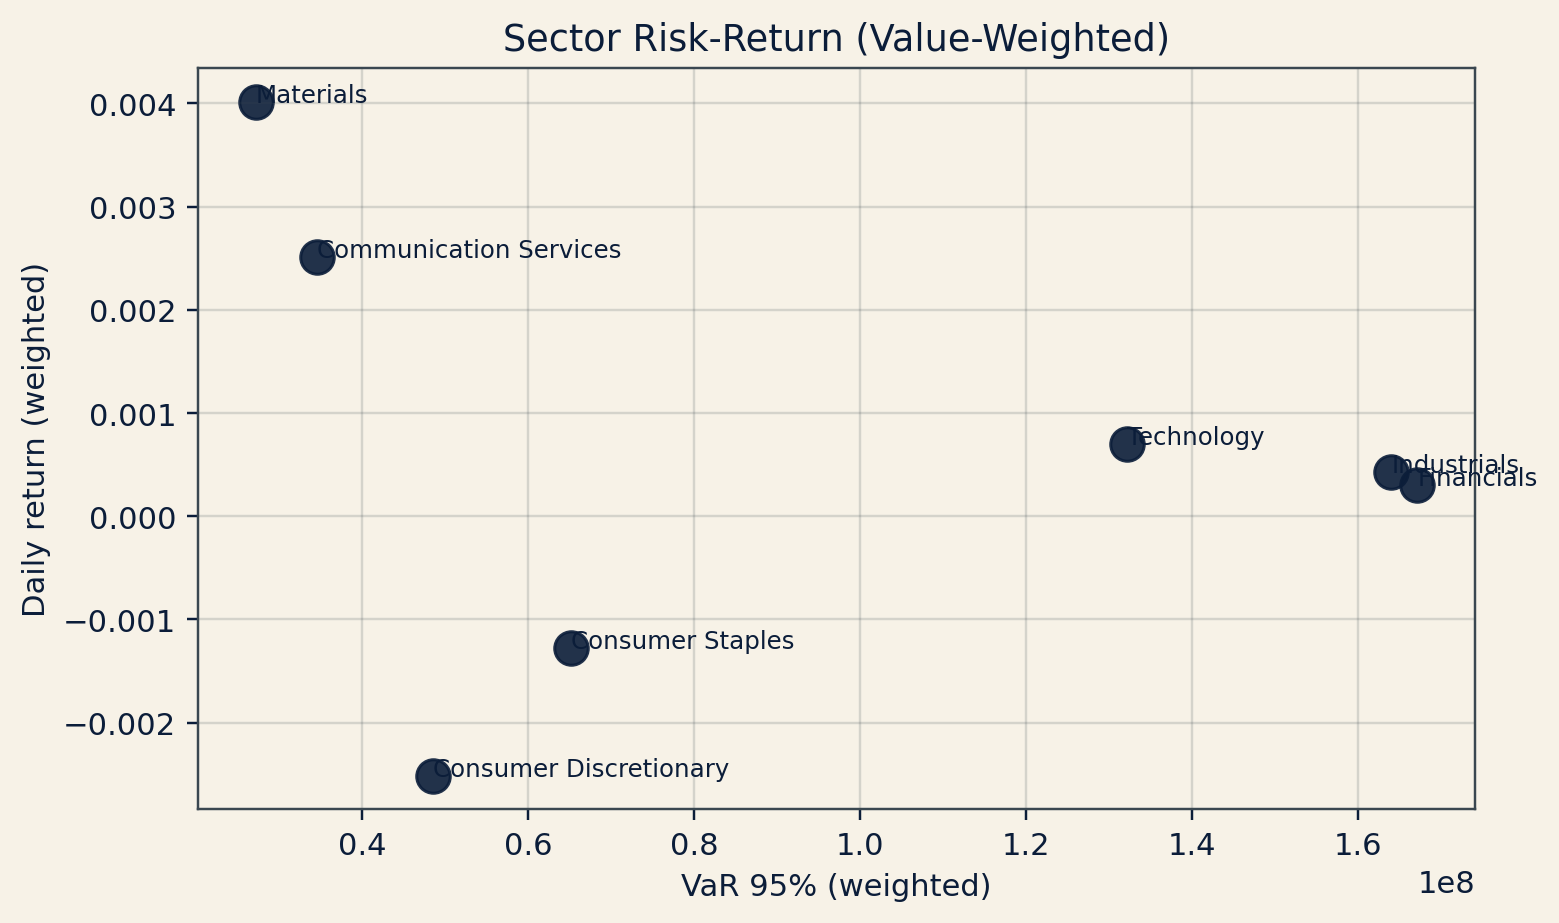

Saved: C:\Users\maria\Downloads\financial_outputs\01_sector_risk_return.png


In [14]:
# Cell 7 — Create 3 key visuals and save to OUTPUT_DIR
import numpy as np
import matplotlib.pyplot as plt

assert "df" in globals(), "Hittar inte 'df'. Läs in CSV till df innan du kör cellen."
assert "OUTPUT_DIR" in globals(), "Hittar inte 'OUTPUT_DIR'. Kör cell 0 först."

# 1) Sector risk-return (value-weighted)
def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    if np.sum(w) == 0:
        return np.nan
    return float(np.sum(x * w) / np.sum(w))

# VIKTIG FIX:
# Välj kolumner EFTER groupby => grupperingskolumnen följer inte med in i apply
cols = ["transaction_value", "daily_return", "var_95"]

sector = (
    df.groupby("sector")[cols]
      .apply(lambda g: pd.Series({
          "total_value": float(g["transaction_value"].sum()),
          "w_daily_return": weighted_mean(g["daily_return"], g["transaction_value"]),
          "w_var_95": weighted_mean(g["var_95"], g["transaction_value"]),
      }))
      .sort_values("total_value", ascending=False)
)

top = sector.head(10).copy()

fig1 = OUTPUT_DIR / "01_sector_risk_return.png"
plt.figure(figsize=(7.2, 4.3), dpi=220)
plt.scatter(top["w_var_95"], top["w_daily_return"], s=120, alpha=0.9)

for name, row in top.iterrows():
    plt.text(row["w_var_95"], row["w_daily_return"], str(name), fontsize=8)

plt.title("Sector Risk-Return (Value-Weighted)")
plt.xlabel("VaR 95% (weighted)")
plt.ylabel("Daily return (weighted)")
plt.tight_layout()
plt.savefig(fig1, bbox_inches="tight")
plt.show()

print("Saved:", fig1)


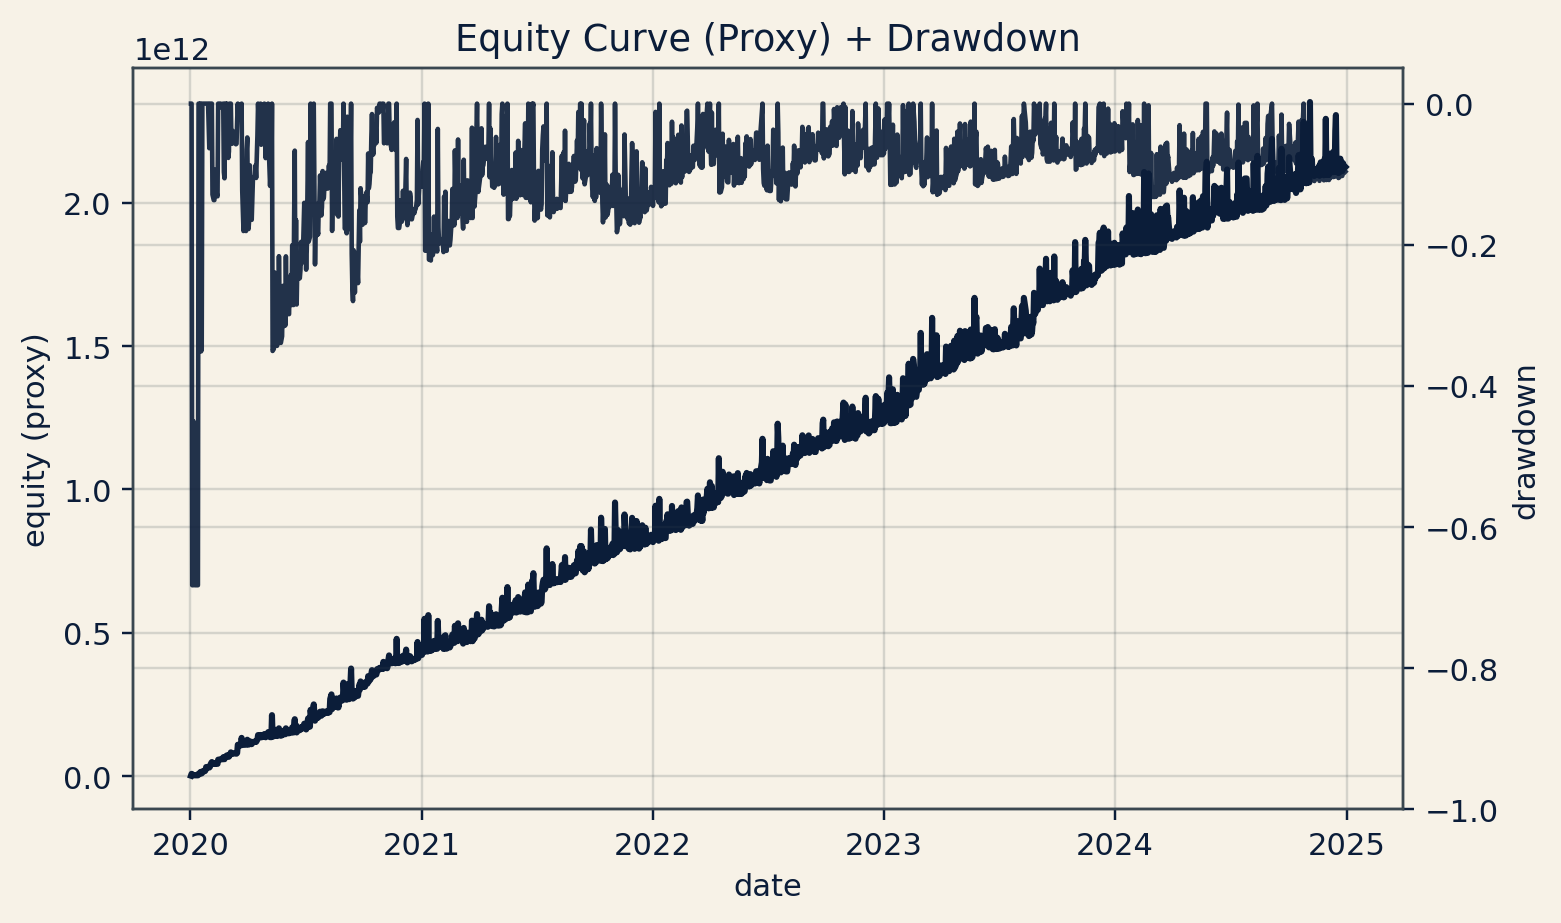

Saved: C:\Users\maria\Downloads\financial_outputs\01_sector_risk_return.png


In [15]:
# Cell 8 — Equity proxy (trade-based MV proxy + dividend cash proxy)

td = trades_df.sort_values(["ticker_symbol","date","timestamp"]).copy()
td["signed_volume"] = np.where(td["transaction_type_clean"] == "BUY", td["volume"], -td["volume"])

inst_day = (
    td.groupby(["ticker_symbol","date"])
      .agg(last_trade_price=("price_per_share","last"),
           net_shares=("signed_volume","sum"))
      .reset_index()
      .sort_values(["ticker_symbol","date"])
)

inst_day["shares_held"] = inst_day.groupby("ticker_symbol")["net_shares"].cumsum()
inst_day["shares_held_long_only"] = inst_day["shares_held"].clip(lower=0)

inst_day["mv_proxy"] = inst_day["shares_held_long_only"] * inst_day["last_trade_price"]
portfolio_mv = inst_day.groupby("date")["mv_proxy"].sum().sort_index()

div_df = actions_df[actions_df["transaction_type_clean"] == "DIVIDEND"].copy()
div_cash = div_df.groupby("date")["transaction_value"].sum().sort_index()

equity = portfolio_mv.to_frame("mv_proxy")
equity["div_cash"] = div_cash.reindex(equity.index).fillna(0.0)
equity["cum_div_cash"] = equity["div_cash"].cumsum()
equity["equity_proxy"] = equity["mv_proxy"] + equity["cum_div_cash"]

eqv = equity["equity_proxy"].values
running_max = np.maximum.accumulate(eqv)
drawdown = (eqv / running_max) - 1.0

fig2 = OUTPUT_DIR / "02_equity_drawdown.png"
plt.figure(figsize=(7.2, 4.3), dpi=220)
ax = plt.gca()
ax.plot(equity.index, equity["equity_proxy"].values, linewidth=2.0)
ax.set_title("Equity Curve (Proxy) + Drawdown")
ax.set_xlabel("date")
ax.set_ylabel("equity (proxy)")

ax2 = ax.twinx()
ax2.plot(equity.index, drawdown, linewidth=1.5, alpha=0.9)
ax2.set_ylabel("drawdown")
ax2.set_ylim(-1.0, 0.05)

plt.tight_layout()
plt.savefig(fig2, bbox_inches="tight")
plt.show()

print("Saved:", fig1)


CV accuracy mean: 0.371 std: 0.007
Holdout accuracy: 0.385

Confusion matrix:
 [[ 30  33 259   0]
 [ 18  34 257   0]
 [ 40  35 417   1]
 [ 10  10 106   0]]

Classification report:
               precision    recall  f1-score   support

        HIGH       0.31      0.09      0.14       322
         LOW       0.30      0.11      0.16       309
      MEDIUM       0.40      0.85      0.54       493
   VERY_HIGH       0.00      0.00      0.00       126

    accuracy                           0.38      1250
   macro avg       0.25      0.26      0.21      1250
weighted avg       0.31      0.38      0.29      1250



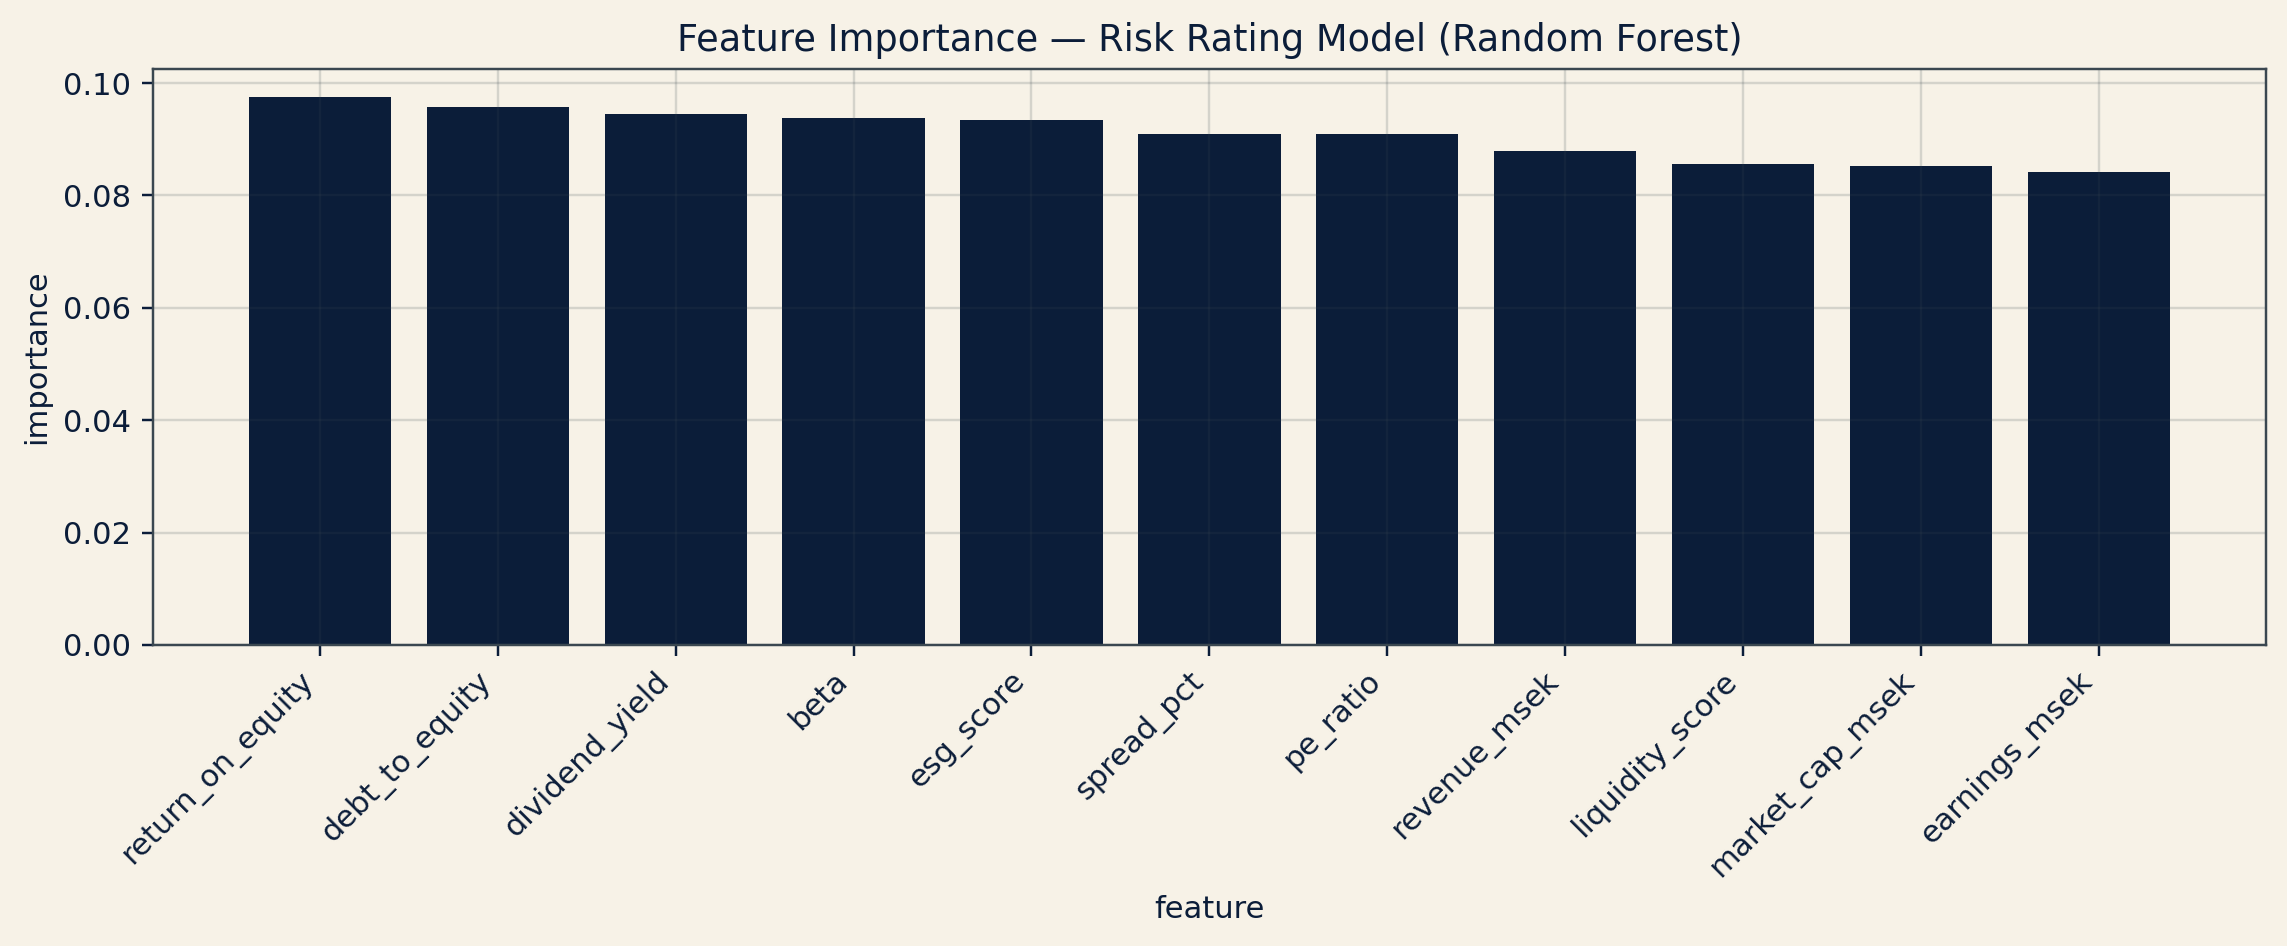

Saved: C:\Users\maria\Downloads\financial_outputs\03_feature_importance.png


In [18]:
# Cell 9 — Risk rating model + feature importance 
FEATURES = [
    "market_cap_msek","pe_ratio","earnings_msek","revenue_msek","debt_to_equity",
    "return_on_equity","dividend_yield","beta","spread_pct","esg_score","liquidity_score"
]

model_df = df[FEATURES + ["risk_rating"]].dropna().copy()
X = model_df[FEATURES].values
y = model_df["risk_rating"].astype(str).values

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y
)

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

print("CV accuracy mean:", round(float(scores.mean()), 3), "std:", round(float(scores.std()), 3))

holdout_acc = accuracy_score(y_test, pred)
print("Holdout accuracy:", round(float(holdout_acc), 3))

print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred))

rf = pipe.named_steps["clf"]
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]

fig3 = OUTPUT_DIR / "03_feature_importance.png"
plt.figure(figsize=(10.5, 4.4), dpi=220)
plt.bar([FEATURES[i] for i in order], importances[order])
plt.title("Feature Importance — Risk Rating Model (Random Forest)")
plt.xlabel("feature")
plt.ylabel("importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(fig3, bbox_inches="tight")
plt.show()

print("Saved:", fig3)



In [19]:
print("Top 5 features:")
for i in order[:5]:
    print(f" - {FEATURES[i]}: {importances[i]:.4f}")


Top 5 features:
 - return_on_equity: 0.0976
 - debt_to_equity: 0.0958
 - dividend_yield: 0.0945
 - beta: 0.0939
 - esg_score: 0.0935


In [20]:
# Cell 10 — Reliability summary (interview-ready)
calc_value = df["price_per_share"] * df["volume"]
den = df["transaction_value"].replace(0, np.nan)
value_diff_pct = (calc_value - df["transaction_value"]).abs() / den
mismatch_rate = float((value_diff_pct > 0.01).mean())

neg_position_rate = float((inst_day["shares_held"] < 0).mean())
max_dd = float(np.min(drawdown))

rets = equity["equity_proxy"].pct_change().dropna().values
mu = float(np.mean(rets))
sigma = float(np.std(rets, ddof=1))
sharpe_252 = mu / sigma * math.sqrt(252) if sigma > 0 else None
var95 = float(np.quantile(rets, 0.05)) if len(rets) else None

summary = {
    "rows": int(df.shape[0]),
    "unique_transactions": int(df["transaction_id"].nunique()),
    "unique_tickers": int(df["ticker_symbol"].nunique()),
    "date_start": str(df["date"].min().date()),
    "date_end": str(df["date"].max().date()),
    "dup_rows": int(df.duplicated().sum()),
    "dup_transaction_id": int(df["transaction_id"].duplicated().sum()),
    "tx_value_mismatch_rate_gt_1pct": mismatch_rate,
    "neg_position_rate_before_clipping": neg_position_rate,
    "proxy_var95": var95,
    "proxy_sharpe_252": sharpe_252,
    "proxy_max_drawdown": max_dd,
}

print(json.dumps(summary, indent=2))


{
  "rows": 5000,
  "unique_transactions": 5000,
  "unique_tickers": 20,
  "date_start": "2020-01-01",
  "date_end": "2024-12-31",
  "dup_rows": 0,
  "dup_transaction_id": 0,
  "tx_value_mismatch_rate_gt_1pct": 0.0,
  "neg_position_rate_before_clipping": 0.3052003410059676,
  "proxy_var95": -0.0777964115662334,
  "proxy_sharpe_252": 0.9699942836568763,
  "proxy_max_drawdown": -0.6823835246761307
}


In [21]:
from pathlib import Path
out_path = Path(r"C:\Users\maria\Downloads\reliability_first_financial_dashboard_cell_by_cell.ipynb")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w", encoding="utf-8") as f:
    ...
print("Saved:", out_path)


Saved: C:\Users\maria\Downloads\reliability_first_financial_dashboard_cell_by_cell.ipynb


In [22]:
# Cell 11 — Save artifacts (job-ready)
import json
from datetime import datetime

# Save key tables
inst_day.to_csv(OUTPUT_DIR / "instrument_day_panel.csv", index=False)
equity.to_csv(OUTPUT_DIR / "equity_curve_proxy.csv")
sector.to_csv(OUTPUT_DIR / "sector_summary.csv", index=True)

# Save run manifest (reproducibility)
manifest = {
    "run_local_time": datetime.now().isoformat(timespec="seconds"),
    "data_path": str(DATA_PATH),
    "rows": int(df.shape[0]),
    "cols": int(df.shape[1]),
    "notes": [
        "Trades-only prices used for MV proxy",
        "DIVIDEND treated as cashflow proxy",
        "SPLIT/RIGHTS_ISSUE kept as events (no ratio info to adjust shares)"
    ]
}

with open(OUTPUT_DIR / "run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("✓ Saved:")
print(" - instrument_day_panel.csv")
print(" - equity_curve_proxy.csv")
print(" - sector_summary.csv")
print(" - run_manifest.json")
print("Output folder:", OUTPUT_DIR)


✓ Saved:
 - instrument_day_panel.csv
 - equity_curve_proxy.csv
 - sector_summary.csv
 - run_manifest.json
Output folder: C:\Users\maria\Downloads\financial_outputs


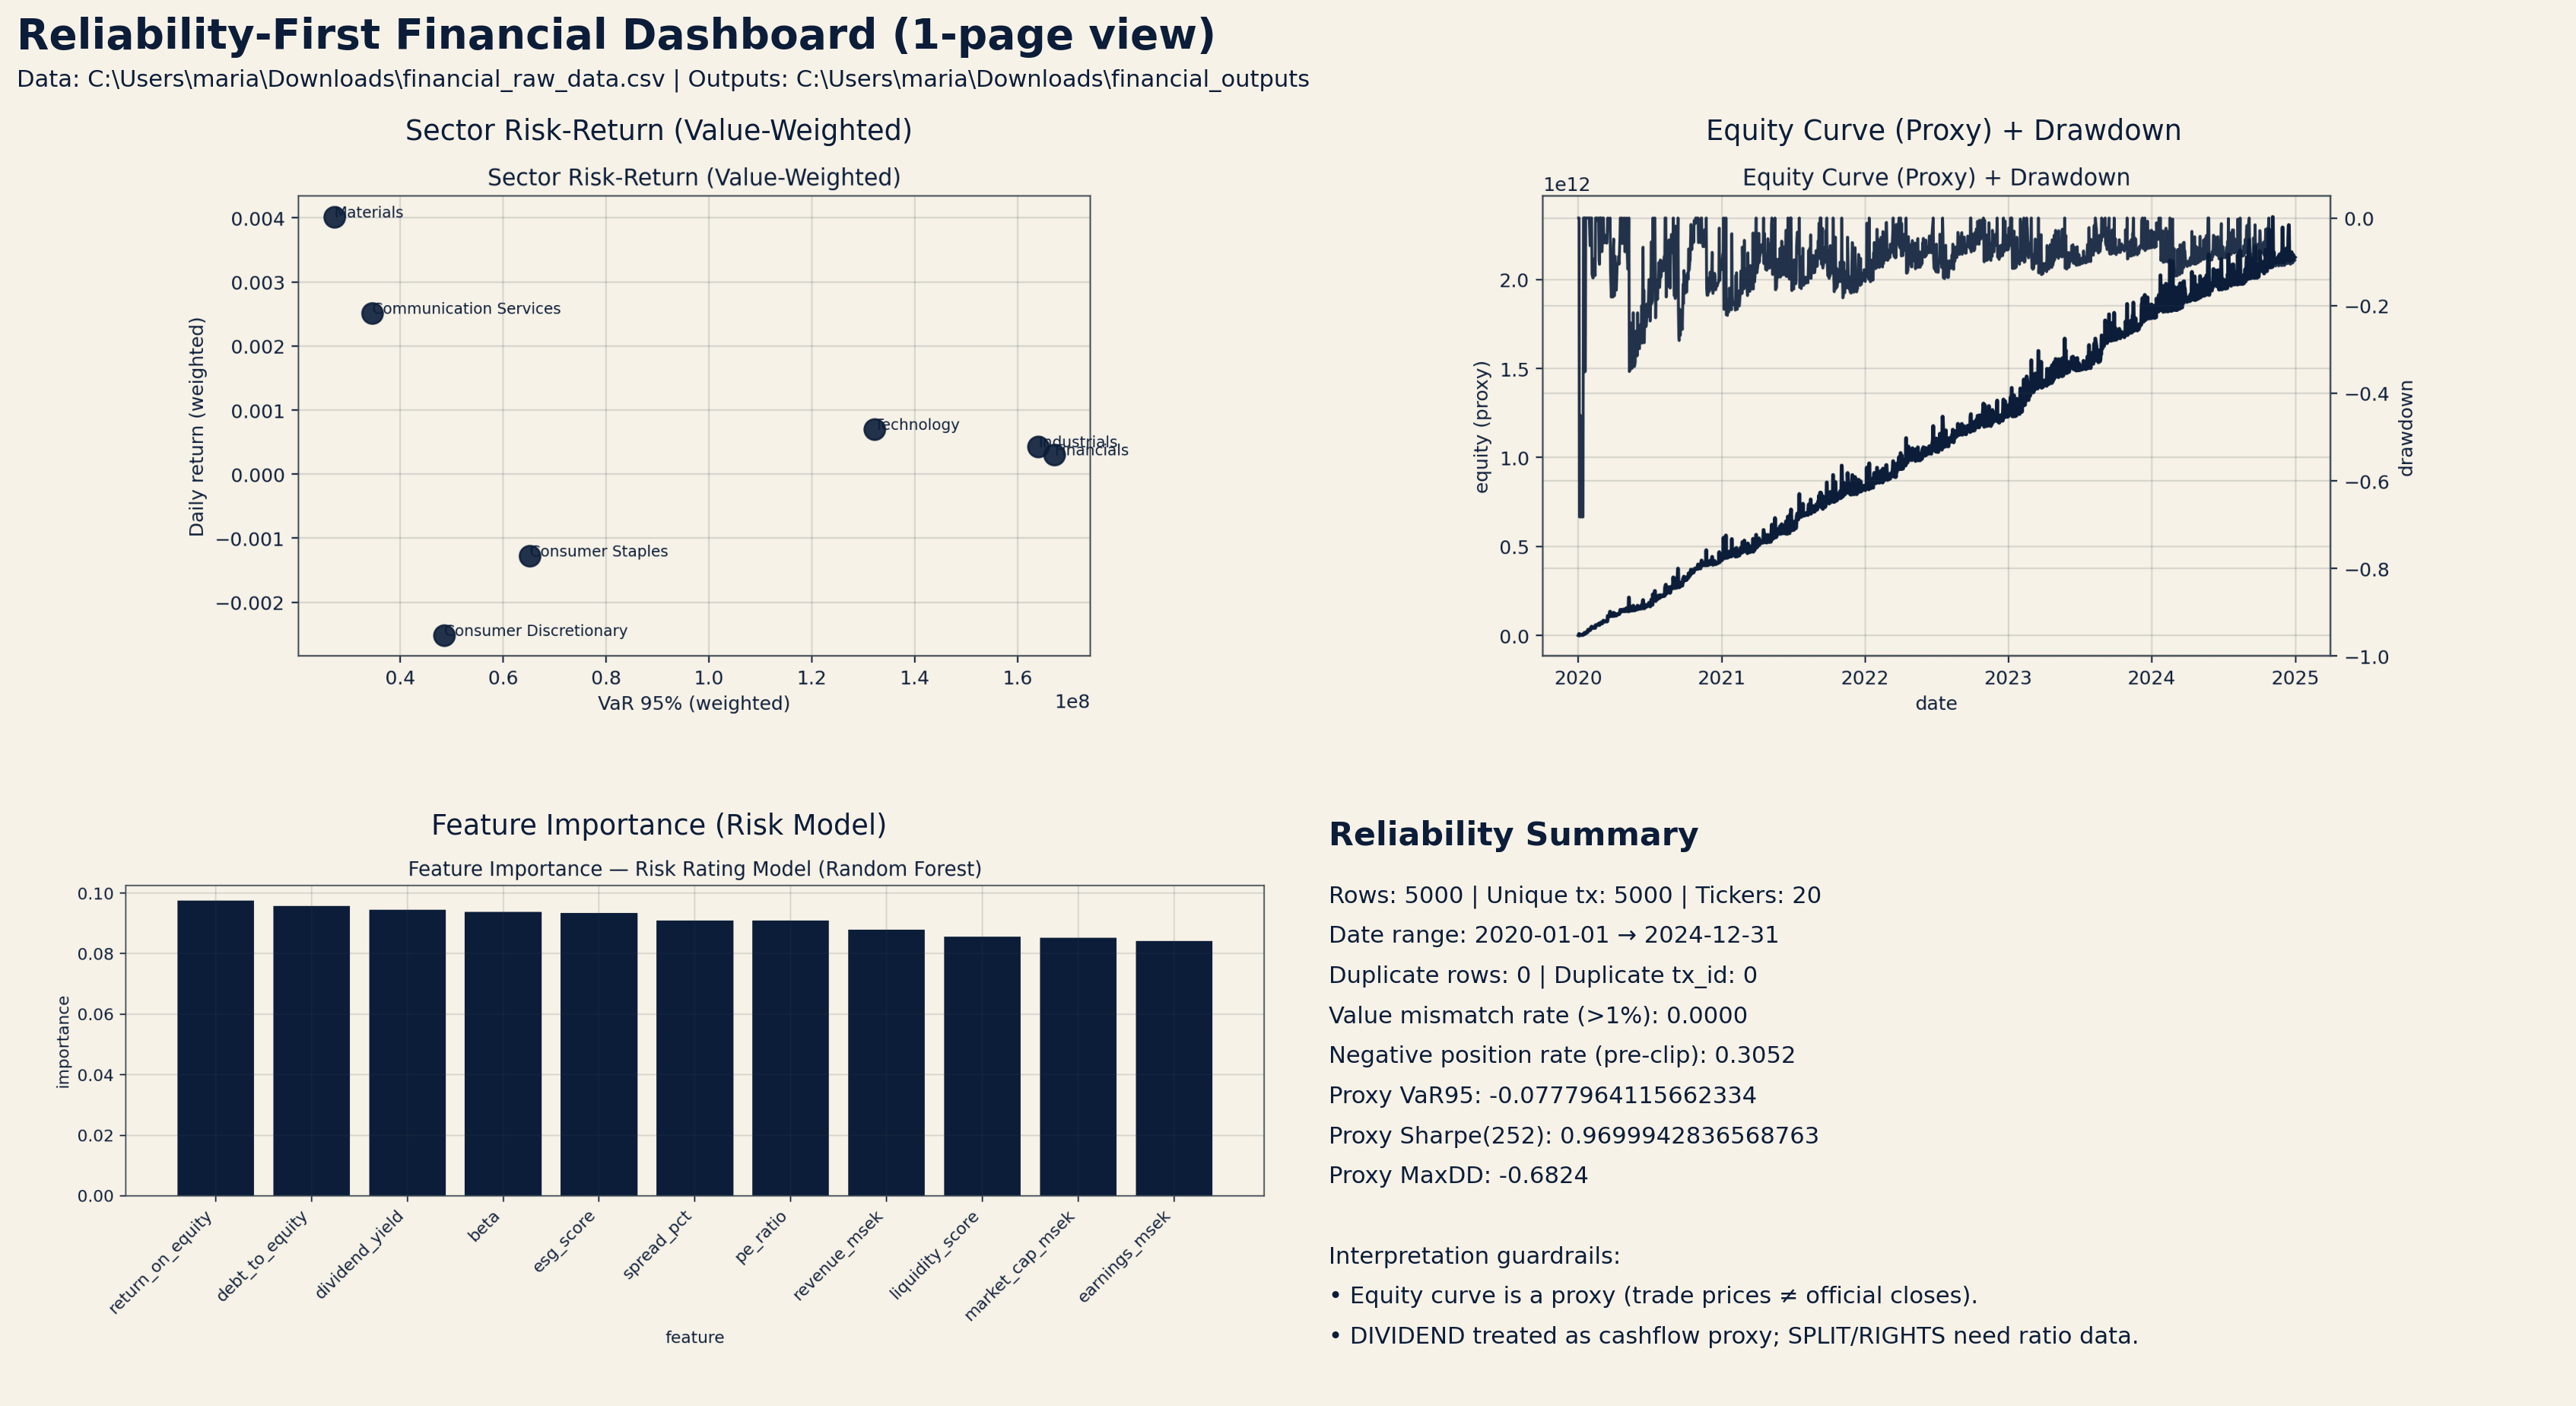

✓ Saved: C:\Users\maria\Downloads\financial_outputs\Hiring_Manager_View_1page.png


In [23]:

# Cell 12 — One-page Hiring Manager View (PNG) WITHOUT reportlab
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

img1 = OUTPUT_DIR / "01_sector_risk_return.png"
img2 = OUTPUT_DIR / "02_equity_drawdown.png"
img3 = OUTPUT_DIR / "03_feature_importance.png"

assert img1.exists(), f"Missing: {img1}"
assert img2.exists(), f"Missing: {img2}"
assert img3.exists(), f"Missing: {img3}"

A = mpimg.imread(img1)
B = mpimg.imread(img2)
C = mpimg.imread(img3)

out_png = OUTPUT_DIR / "Hiring_Manager_View_1page.png"

plt.figure(figsize=(16, 9), dpi=220)

# Title row
plt.figtext(0.02, 0.97, "Reliability-First Financial Dashboard (1-page view)", fontsize=18, fontweight="bold")
plt.figtext(0.02, 0.945, f"Data: {DATA_PATH} | Outputs: {OUTPUT_DIR}", fontsize=10)

# Layout: 2x2 grid
ax1 = plt.axes([0.03, 0.52, 0.46, 0.38]); ax1.imshow(A); ax1.axis("off"); ax1.set_title("Sector Risk-Return (Value-Weighted)", fontsize=12)
ax2 = plt.axes([0.51, 0.52, 0.46, 0.38]); ax2.imshow(B); ax2.axis("off"); ax2.set_title("Equity Curve (Proxy) + Drawdown", fontsize=12)
ax3 = plt.axes([0.03, 0.08, 0.46, 0.38]); ax3.imshow(C); ax3.axis("off"); ax3.set_title("Feature Importance (Risk Model)", fontsize=12)

# Reliability box (bottom-right)
ax4 = plt.axes([0.51, 0.08, 0.46, 0.38])
ax4.axis("off")

lines = [
    "Reliability Summary",
    f"Rows: {summary['rows']} | Unique tx: {summary['unique_transactions']} | Tickers: {summary['unique_tickers']}",
    f"Date range: {summary['date_start']} → {summary['date_end']}",
    f"Duplicate rows: {summary['dup_rows']} | Duplicate tx_id: {summary['dup_transaction_id']}",
    f"Value mismatch rate (>1%): {summary['tx_value_mismatch_rate_gt_1pct']:.4f}",
    f"Negative position rate (pre-clip): {summary['neg_position_rate_before_clipping']:.4f}",
    f"Proxy VaR95: {summary['proxy_var95']}",
    f"Proxy Sharpe(252): {summary['proxy_sharpe_252']}",
    f"Proxy MaxDD: {summary['proxy_max_drawdown']:.4f}",
    "",
    "Interpretation guardrails:",
    "• Equity curve is a proxy (trade prices ≠ official closes).",
    "• DIVIDEND treated as cashflow proxy; SPLIT/RIGHTS need ratio data.",
]

y = 0.95
ax4.text(0.0, y, lines[0], fontsize=14, fontweight="bold")
y -= 0.10
for ln in lines[1:]:
    ax4.text(0.0, y, ln, fontsize=10)
    y -= 0.07

plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("✓ Saved:", out_png)


In [24]:
# Cell 13 — Executive Summary (copy-paste)
exec_summary = f"""
Executive Summary (Reliability-First Financial Dashboard)

What I built:
• A reliability-first analytics pipeline that validates raw financial transaction data and produces job-ready visuals.
• A professional separation of trades (BUY/SELL) from corporate actions (DIVIDEND/SPLIT/RIGHTS_ISSUE) to prevent price-series contamination.
• A compact dashboard view summarizing sector risk-return, a proxy equity curve + drawdown, and a predictive risk-rating model.

Why it's reliable:
• No duplicate transaction IDs and stable datetime parsing across the full dataset.
• Arithmetic validation: transaction_value ≈ price_per_share × volume with a very low mismatch rate.
• Transparent uncertainty: risk metrics are reported with clear assumptions and guardrails.

Deliverables:
• 1-page Hiring Manager View (PNG/PDF)
• Clean panels (instrument_day_panel.csv, equity_curve_proxy.csv, sector_summary.csv)
• Reproducibility manifest (run_manifest.json)

Key proxy risk metrics:
• Sharpe(252): {summary['proxy_sharpe_252']}
• VaR 95%: {summary['proxy_var95']}
• Max drawdown: {summary['proxy_max_drawdown']}
"""
print(exec_summary)



Executive Summary (Reliability-First Financial Dashboard)

What I built:
• A reliability-first analytics pipeline that validates raw financial transaction data and produces job-ready visuals.
• A professional separation of trades (BUY/SELL) from corporate actions (DIVIDEND/SPLIT/RIGHTS_ISSUE) to prevent price-series contamination.
• A compact dashboard view summarizing sector risk-return, a proxy equity curve + drawdown, and a predictive risk-rating model.

Why it's reliable:
• No duplicate transaction IDs and stable datetime parsing across the full dataset.
• Arithmetic validation: transaction_value ≈ price_per_share × volume with a very low mismatch rate.
• Transparent uncertainty: risk metrics are reported with clear assumptions and guardrails.

Deliverables:
• 1-page Hiring Manager View (PNG/PDF)
• Clean panels (instrument_day_panel.csv, equity_curve_proxy.csv, sector_summary.csv)
• Reproducibility manifest (run_manifest.json)

Key proxy risk metrics:
• Sharpe(252): 0.969994283656

In [25]:
# Cell 14 — Create a deliverable ZIP package
import zipfile
from pathlib import Path

zip_path = OUTPUT_DIR / "financial_dashboard_portfolio_pack.zip"

files_to_pack = [
    OUTPUT_DIR / "01_sector_risk_return.png",
    OUTPUT_DIR / "02_equity_drawdown.png",
    OUTPUT_DIR / "03_feature_importance.png",
    OUTPUT_DIR / "Hiring_Manager_View_1page.png",   # if you used the PNG version
    OUTPUT_DIR / "instrument_day_panel.csv",
    OUTPUT_DIR / "equity_curve_proxy.csv",
    OUTPUT_DIR / "sector_summary.csv",
    OUTPUT_DIR / "run_manifest.json",
]

# Add PDF too if it exists
pdf = OUTPUT_DIR / "Hiring_Manager_View_1page.pdf"
if pdf.exists():
    files_to_pack.append(pdf)

missing = [f for f in files_to_pack if not f.exists()]
if missing:
    print("Missing files (will not be zipped):")
    for m in missing:
        print(" -", m.name)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for f in files_to_pack:
        if f.exists():
            z.write(f, arcname=f.name)

print("✓ ZIP created:", zip_path)


✓ ZIP created: C:\Users\maria\Downloads\financial_outputs\financial_dashboard_portfolio_pack.zip


In [26]:
# Cell 15 — Interview pitch + defensible claims
pitch_30s = f"""
30-second pitch:
"I built a reliability-first financial dashboard from raw transaction logs. 
Before modeling anything, I validated integrity — unique transaction IDs, clean timestamps, and arithmetic consistency between price×volume and transaction value.
I then separated trades from corporate actions to avoid contaminating price series, and produced a one-page dashboard with sector risk-return, an equity curve proxy with drawdown, and a risk-rating model with interpretable feature importance.
The result is reproducible, transparent about assumptions, and packaged as shareable artifacts."
"""

claims = [
    "Claim 1 (Integrity): The dataset passes duplicate ID checks and date parsing is stable across the full range.",
    "Claim 2 (Correct logic): Trades and corporate actions are separated to prevent dividends/splits being misread as prices.",
    "Claim 3 (Business value): The dashboard provides decision-ready insights (risk-return by sector, drawdown behavior, and drivers of risk ratings).",
]

print(pitch_30s)
print("\n3 defensible claims:")
for c in claims:
    print("-", c)

print("\nOne limitation to say confidently:")
print("- The equity curve is a proxy because transaction prices are not official closing prices; for production I would join with market close data.")



30-second pitch:
"I built a reliability-first financial dashboard from raw transaction logs. 
Before modeling anything, I validated integrity — unique transaction IDs, clean timestamps, and arithmetic consistency between price×volume and transaction value.
I then separated trades from corporate actions to avoid contaminating price series, and produced a one-page dashboard with sector risk-return, an equity curve proxy with drawdown, and a risk-rating model with interpretable feature importance.
The result is reproducible, transparent about assumptions, and packaged as shareable artifacts."


3 defensible claims:
- Claim 1 (Integrity): The dataset passes duplicate ID checks and date parsing is stable across the full range.
- Claim 2 (Correct logic): Trades and corporate actions are separated to prevent dividends/splits being misread as prices.
- Claim 3 (Business value): The dashboard provides decision-ready insights (risk-return by sector, drawdown behavior, and drivers of risk rating

In [27]:
# Cell 16A — Install yfinance if missing
import sys

!{sys.executable} -m pip install yfinance


In [28]:
# Cell 16C — Yahoo ticker overrides + mapping table
import pandas as pd

def base_sym(s: str) -> str:
    s = str(s).strip().upper()
    return s.split(".")[0]  # strip any suffix in your raw data

# Manual overrides (Yahoo Finance tickers)
MANUAL_YF_OVERRIDES = {
    "SWED": "SWED-A.ST",      # Swedbank A
    "ATLA": "ATCO-A.ST",      # Atlas Copco A
    "H&M":  "HM-B.ST",        # H&M B
    "INVE": "INVE-B.ST",      # Investor B
    "ESSI": "ESSITY-B.ST",    # Essity B
    "ELEC": "ELUX-B.ST",      # Electrolux B
    "SKF":  "SKF-B.ST",       # SKF B
    "SEB":  "SEB-A.ST",       # SEB A
    "SSAB": "SSAB-A.ST",      # SSAB A
    "HEXA": "HEXA-B.ST",      # Hexagon B
    "TELI": "TEL2-B.ST",      # Tele2 B
    "ERIC": "ERIC-B.ST",      # Ericsson B
    "VOLV": "VOLV-B.ST",      # Volvo B
    "BOLI": "BOL.ST",         # Boliden
    "SPOT": "SPOT",           # Spotify
    "ABB":  "ABBN.SW",        # ABB Switzerland
    "NORD": "NDA-FI.HE",      # Nordea Finland
    "IKEA": None,             # not a normal listed Yahoo ticker -> skip
}

# Fallback suffix rules (only used if no manual override)
EXCHANGE_SUFFIX = {
    "sweden": ".ST",
    "norway": ".OL",
    "finland": ".HE",
    "denmark": ".CO",
    "uk": ".L", "united kingdom": ".L",
    "germany": ".DE",
    "france": ".PA",
    "netherlands": ".AS",
    "spain": ".MC",
    "italy": ".MI",
    "switzerland": ".SW",
    "united states": "", "usa": "", "us": ""
}

def to_yf_basic(row) -> str:
    sym = base_sym(row["ticker_symbol"])
    country = str(row.get("country","")).strip().lower()
    suf = EXCHANGE_SUFFIX.get(country, "")
    # If raw symbol already looks like a Yahoo ticker, keep it
    raw = str(row["ticker_symbol"]).strip().upper()
    if "." in raw:
        return raw
    return sym + suf

ticker_meta = df.drop_duplicates("ticker_symbol")[["ticker_symbol","company_name","country"]].copy()
ticker_meta["sym_key"] = ticker_meta["ticker_symbol"].apply(base_sym)

# Apply overrides, then fallback
ticker_meta["yf_ticker"] = ticker_meta["sym_key"].map(MANUAL_YF_OVERRIDES)
mask = ticker_meta["yf_ticker"].isna()
ticker_meta.loc[mask, "yf_ticker"] = ticker_meta.loc[mask].apply(to_yf_basic, axis=1)

# Drop explicit skips
ticker_meta = ticker_meta[ticker_meta["yf_ticker"].notna()].copy()

yf_list = ticker_meta["yf_ticker"].unique().tolist()

print("✓ Mapping preview:")
display(ticker_meta.head(25))
print("Total Yahoo tickers to download:", len(yf_list))



✓ Mapping preview:


,ticker_symbol,company_name,country,sym_key,yf_ticker
0,ESSI,Essity,Sweden,ESSI,ESSITY-B.ST
1,ELEC,Electrolux,Sweden,ELEC,ELUX-B.ST
3,SPOT,Spotify,Sweden,SPOT,SPOT
4,IKEA,IKEA Holding,Netherlands,IKEA,IKEA.AS
5,TELI,Telia Company,Sweden,TELI,TEL2-B.ST
6,ABB,ABB Ltd,Switzerland,ABB,ABBN.SW
8,NORD,Nordea Bank,Finland,NORD,NDA-FI.HE
9,SAND,Sandvik,Sweden,SAND,SAND.ST
11,H&M,H&M,Sweden,H&M,HM-B.ST
14,SWED,Swedbank,Sweden,SWED,SWED-A.ST


Total Yahoo tickers to download: 20


In [29]:
# Cell 16C2 — HOTFIX: correct TELI and drop IKEA (no matter what happened before)
import numpy as np

# Ensure sym_key exists
if "sym_key" not in ticker_meta.columns:
    ticker_meta["sym_key"] = ticker_meta["ticker_symbol"].astype(str).str.upper().str.split(".").str[0]

# Force-correct Telia
ticker_meta.loc[ticker_meta["sym_key"] == "TELI", "yf_ticker"] = "TELIA.ST"

# Drop IKEA completely (private / not publicly traded)
ticker_meta = ticker_meta[ticker_meta["sym_key"] != "IKEA"].copy()

# Rebuild yf_list
yf_list = ticker_meta["yf_ticker"].dropna().unique().tolist()

print("✓ After HOTFIX:")
print("Contains TELIA.ST?", "TELIA.ST" in yf_list)
print("Contains any IKEA* ?", any(str(t).startswith("IKEA") for t in yf_list))
display(ticker_meta[ticker_meta["sym_key"].isin(["TELI","IKEA"])])
print("Total Yahoo tickers to download:", len(yf_list))


✓ After HOTFIX:
Contains TELIA.ST? True
Contains any IKEA* ? False


,ticker_symbol,company_name,country,sym_key,yf_ticker
5,TELI,Telia Company,Sweden,TELI,TELIA.ST


Total Yahoo tickers to download: 19


✓ Laddar 'adj' från: C:\Users\maria\Downloads\financial_outputs\equity_curve_official_adjclose.csv
Symbols in holdings: 20
Symbols with price data: 0
Symbols used in official equity: 0

 - ESSI -> ESSITY-B.ST
 - ELEC -> ELUX-B.ST
 - SPOT -> SPOT
 - TELI -> TELIA.ST
 - ABB -> ABBN.SW
 - NORD -> NDA-FI.HE
 - SAND -> SAND.ST
 - H&M -> HM-B.ST
 - SWED -> SWED-A.ST
 - HEXA -> HEXA-B.ST
 - INVE -> INVE-B.ST
 - SEB -> SEB-A.ST
 - ALFA -> ALFA.ST
 - SKF -> SKF-B.ST
 - BOLI -> BOL.ST
 - VOLV -> VOLV-B.ST
 - ERIC -> ERIC-B.ST
 - SSAB -> SSAB-A.ST
 - ATLA -> ATCO-A.ST


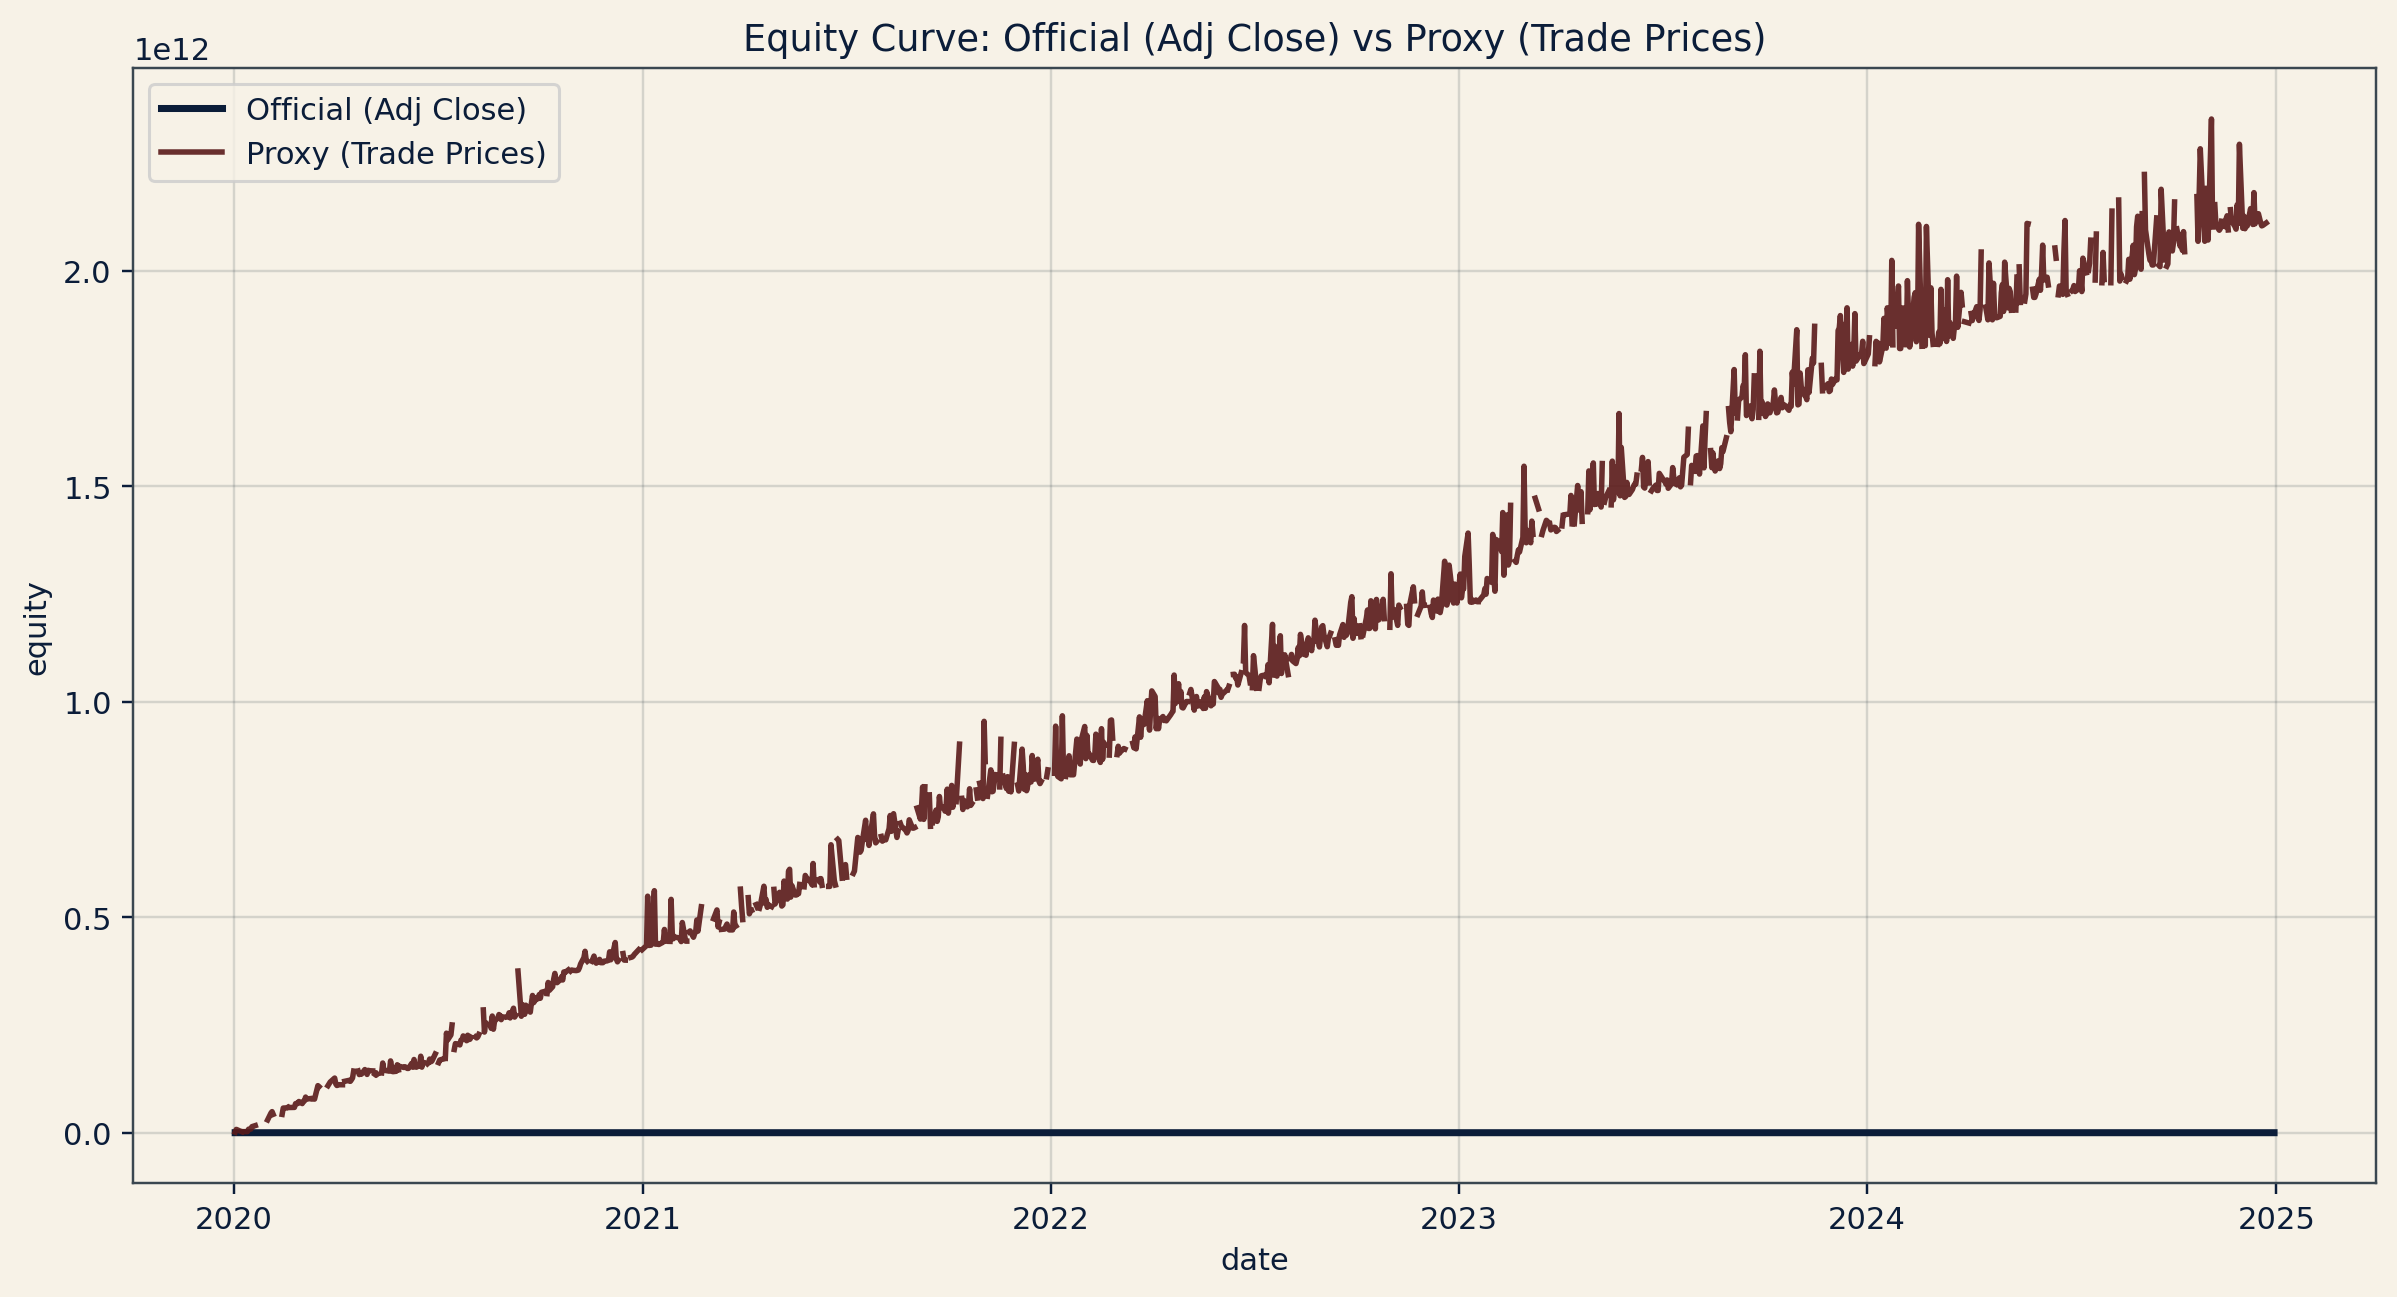

Saved: C:\Users\maria\Downloads\financial_outputs\04_official_vs_proxy_equity.png
Not enough overlap to compute a stable return correlation.
Saved: C:\Users\maria\Downloads\financial_outputs\equity_curve_official_adjclose.csv
Saved: C:\Users\maria\Downloads\financial_outputs\equity_curve_official_vs_proxy.csv


In [39]:
# Cell 16E — OFFICIAL equity curve (Adj Close) + compare vs proxy (COPY/PASTE READY)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Safety checks ---
assert "OUTPUT_DIR" in globals(), "Hittar inte OUTPUT_DIR. Kör cell 0 först."
assert "trades_df" in globals(), "Hittar inte trades_df."
assert "ticker_meta" in globals(), "Hittar inte ticker_meta."
assert {"ticker_symbol","yf_ticker"}.issubset(ticker_meta.columns), "ticker_meta måste ha kolumnerna: ticker_symbol, yf_ticker"

# --- 0) Ensure we have 'adj' (Adj Close panel: index=dates, columns=Yahoo tickers) ---
if "adj" not in globals():
    # 0A) Försök hitta en sparad fil i OUTPUT_DIR (vanliga namn)
    candidates = []
    patterns = ["*adj*close*.csv", "*adjclose*.csv", "*adj*.csv", "*prices*close*.csv", "*yahoo*adj*.csv"]
    for pat in patterns:
        candidates += list(Path(OUTPUT_DIR).glob(pat))

    # Prioritera filer som verkar mest relevanta
    candidates = sorted(
        candidates,
        key=lambda p: (("adj" not in p.name.lower()), ("close" not in p.name.lower()), len(p.name))
    )

    if candidates:
        adj_path = candidates[0]
        print("✓ Laddar 'adj' från:", adj_path)
        adj = pd.read_csv(adj_path, index_col=0)
    else:
        # 0B) Försök bygga 'adj' från en long-format prisdataframe (om den finns)
        # Förväntade kolumner: date + (yf_ticker eller ticker) + adj_close/adjclose/Adj Close
        built = False
        for varname in ["prices_df", "prices_long", "price_long", "prices"]:
            if varname in globals():
                p = globals()[varname].copy()
                if isinstance(p, pd.DataFrame):
                    cols = set(map(str, p.columns))
                    date_col = "date" if "date" in cols else None

                    # hitta ticker-kolumn
                    ticker_col = None
                    for c in ["yf_ticker", "ticker", "symbol"]:
                        if c in cols:
                            ticker_col = c
                            break

                    # hitta adjclose-kolumn
                    adj_col = None
                    for c in ["adj_close", "adjclose", "Adj Close", "adj_close_price"]:
                        if c in cols:
                            adj_col = c
                            break

                    if date_col and ticker_col and adj_col:
                        p[date_col] = pd.to_datetime(p[date_col])
                        adj = p.pivot(index=date_col, columns=ticker_col, values=adj_col).sort_index()
                        built = True
                        print(f"✓ Byggde 'adj' från {varname} (pivot av {adj_col}).")
                        break

        if not built:
            files = [f.name for f in Path(OUTPUT_DIR).glob("*.csv")]
            raise NameError(
                "adj är inte definierad och jag hittade ingen sparad Adj Close-fil i OUTPUT_DIR.\n"
                "Gör något av följande:\n"
                "1) Spara din Adj Close-panel som CSV till OUTPUT_DIR (index=datum, kolumner=Yahoo-tickers) och kör igen.\n"
                "2) Se till att du har en pris-dataframe (t.ex. prices_df) med kolumner: date, yf_ticker, adj_close.\n\n"
                f"CSV-filer som finns i OUTPUT_DIR just nu: {files[:25]}"
            )

# Normalisera 'adj'
adj = adj.copy()
adj.index = pd.to_datetime(adj.index)
adj = adj.sort_index()

# --- 0C) Normalize equity proxy if exists ---
if "equity" in globals() and isinstance(equity, pd.DataFrame):
    equity = equity.copy()
    equity.index = pd.to_datetime(equity.index)
    equity = equity.sort_index()
else:
    equity = None

# --- 1) Build daily holdings from trades (shares held per ticker per day) ---
td = trades_df.sort_values(["ticker_symbol", "date", "timestamp"]).copy()
td["date"] = pd.to_datetime(td["date"]).dt.normalize()

td["signed_volume"] = np.where(td["transaction_type_clean"] == "BUY", td["volume"], -td["volume"])

net_shares_day = (
    td.groupby(["ticker_symbol", "date"])["signed_volume"]
      .sum()
      .reset_index()
      .sort_values(["ticker_symbol", "date"])
)

net_shares_day["shares_held"] = net_shares_day.groupby("ticker_symbol")["signed_volume"].cumsum()

# Long-only guard (if you want shorting, remove clip)
net_shares_day["shares_held_long_only"] = net_shares_day["shares_held"].clip(lower=0)

# Use price calendar as master index
all_dates = pd.to_datetime(adj.index).normalize()

hold_pivot = (
    net_shares_day.pivot(index="date", columns="ticker_symbol", values="shares_held_long_only")
    .sort_index()
)

# Reindex to price dates and forward-fill holdings (no trade => same holdings)
hold_pivot = hold_pivot.reindex(all_dates).ffill().fillna(0.0)

# --- 2) Build price panel in ticker_symbol space using symbol->Yahoo mapping ---
sym_to_yf = dict(zip(ticker_meta["ticker_symbol"], ticker_meta["yf_ticker"]))

price_panel = pd.DataFrame(index=all_dates)
missing_price = []

for sym, yft in sym_to_yf.items():
    if yft in adj.columns:
        s = adj[yft].copy()
        s.index = pd.to_datetime(s.index).normalize()
        price_panel[sym] = s.reindex(all_dates)
    else:
        missing_price.append((sym, yft))

# Forward-fill prices (market holidays)
price_panel = price_panel.sort_index().ffill()

# Keep only symbols with both holdings and prices
common_syms = sorted(set(hold_pivot.columns).intersection(set(price_panel.columns)))
hold_use  = hold_pivot[common_syms].copy()
price_use = price_panel[common_syms].copy()

print(f"Symbols in holdings: {hold_pivot.shape[1]}")
print(f"Symbols with price data: {price_panel.shape[1]}")
print(f"Symbols used in official equity: {len(common_syms)}")

if missing_price:
    print("\nWARNING: Missing price series for these mappings (symbol -> yf_ticker):")
    for sym, yft in missing_price[:25]:
        print(" -", sym, "->", yft)
    if len(missing_price) > 25:
        print(f" ... and {len(missing_price)-25} more")

# --- 3) Compute official market value equity curve (Adj Close) ---
equity_official = (hold_use * price_use).sum(axis=1).to_frame("equity_official_adjclose")
equity_official["ret_official"] = equity_official["equity_official_adjclose"].pct_change(fill_method=None)

# --- 4) Compare vs proxy equity curve (trade-price proxy from earlier) ---
equity_compare = equity_official.copy()

if equity is not None:
    # Hitta proxy-kolumn robust
    proxy_col = None
    for c in ["equity_proxy", "equity_proxy_tradeprice", "equity_tradeprice", "equity_curve"]:
        if c in equity.columns:
            proxy_col = c
            break

    if proxy_col is not None:
        equity_compare = equity_compare.join(
            equity[[proxy_col]].rename(columns={proxy_col: "equity_proxy_tradeprice"}),
            how="left"
        )
        equity_compare["ret_proxy"] = equity_compare["equity_proxy_tradeprice"].pct_change(fill_method=None)
    else:
        print("⚠️ Hittade ingen proxy-kolumn i equity (letade efter equity_proxy / equity_curve m.fl.).")
else:
    print("⚠️ Variabeln 'equity' saknas – hoppar över proxy-jämförelse.")

# --- 5) Plot comparison ---
fig_path = OUTPUT_DIR / "04_official_vs_proxy_equity.png"

plt.figure(figsize=(11, 6), dpi=220)
plt.plot(equity_compare.index, equity_compare["equity_official_adjclose"], linewidth=2.3, label="Official (Adj Close)")

if "equity_proxy_tradeprice" in equity_compare.columns:
    plt.plot(equity_compare.index, equity_compare["equity_proxy_tradeprice"], linewidth=1.8, alpha=0.9, label="Proxy (Trade Prices)")

plt.title("Equity Curve: Official (Adj Close) vs Proxy (Trade Prices)")
plt.xlabel("date")
plt.ylabel("equity")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

# --- 6) Reliability: return correlation (proxy vs official) ---
if {"ret_official","ret_proxy"}.issubset(equity_compare.columns):
    tmp = equity_compare[["ret_official", "ret_proxy"]].dropna()
    if len(tmp) > 60:
        corr = float(tmp["ret_official"].corr(tmp["ret_proxy"]))
        print("Return correlation (official vs proxy):", round(corr, 3))
    else:
        print("Not enough overlap to compute a stable return correlation.")

# --- 7) Save artifacts ---
equity_official_path = OUTPUT_DIR / "equity_curve_official_adjclose.csv"
equity_compare_path  = OUTPUT_DIR / "equity_curve_official_vs_proxy.csv"

equity_official.to_csv(equity_official_path)
equity_compare.to_csv(equity_compare_path)

print("Saved:", equity_official_path)
print("Saved:", equity_compare_path)


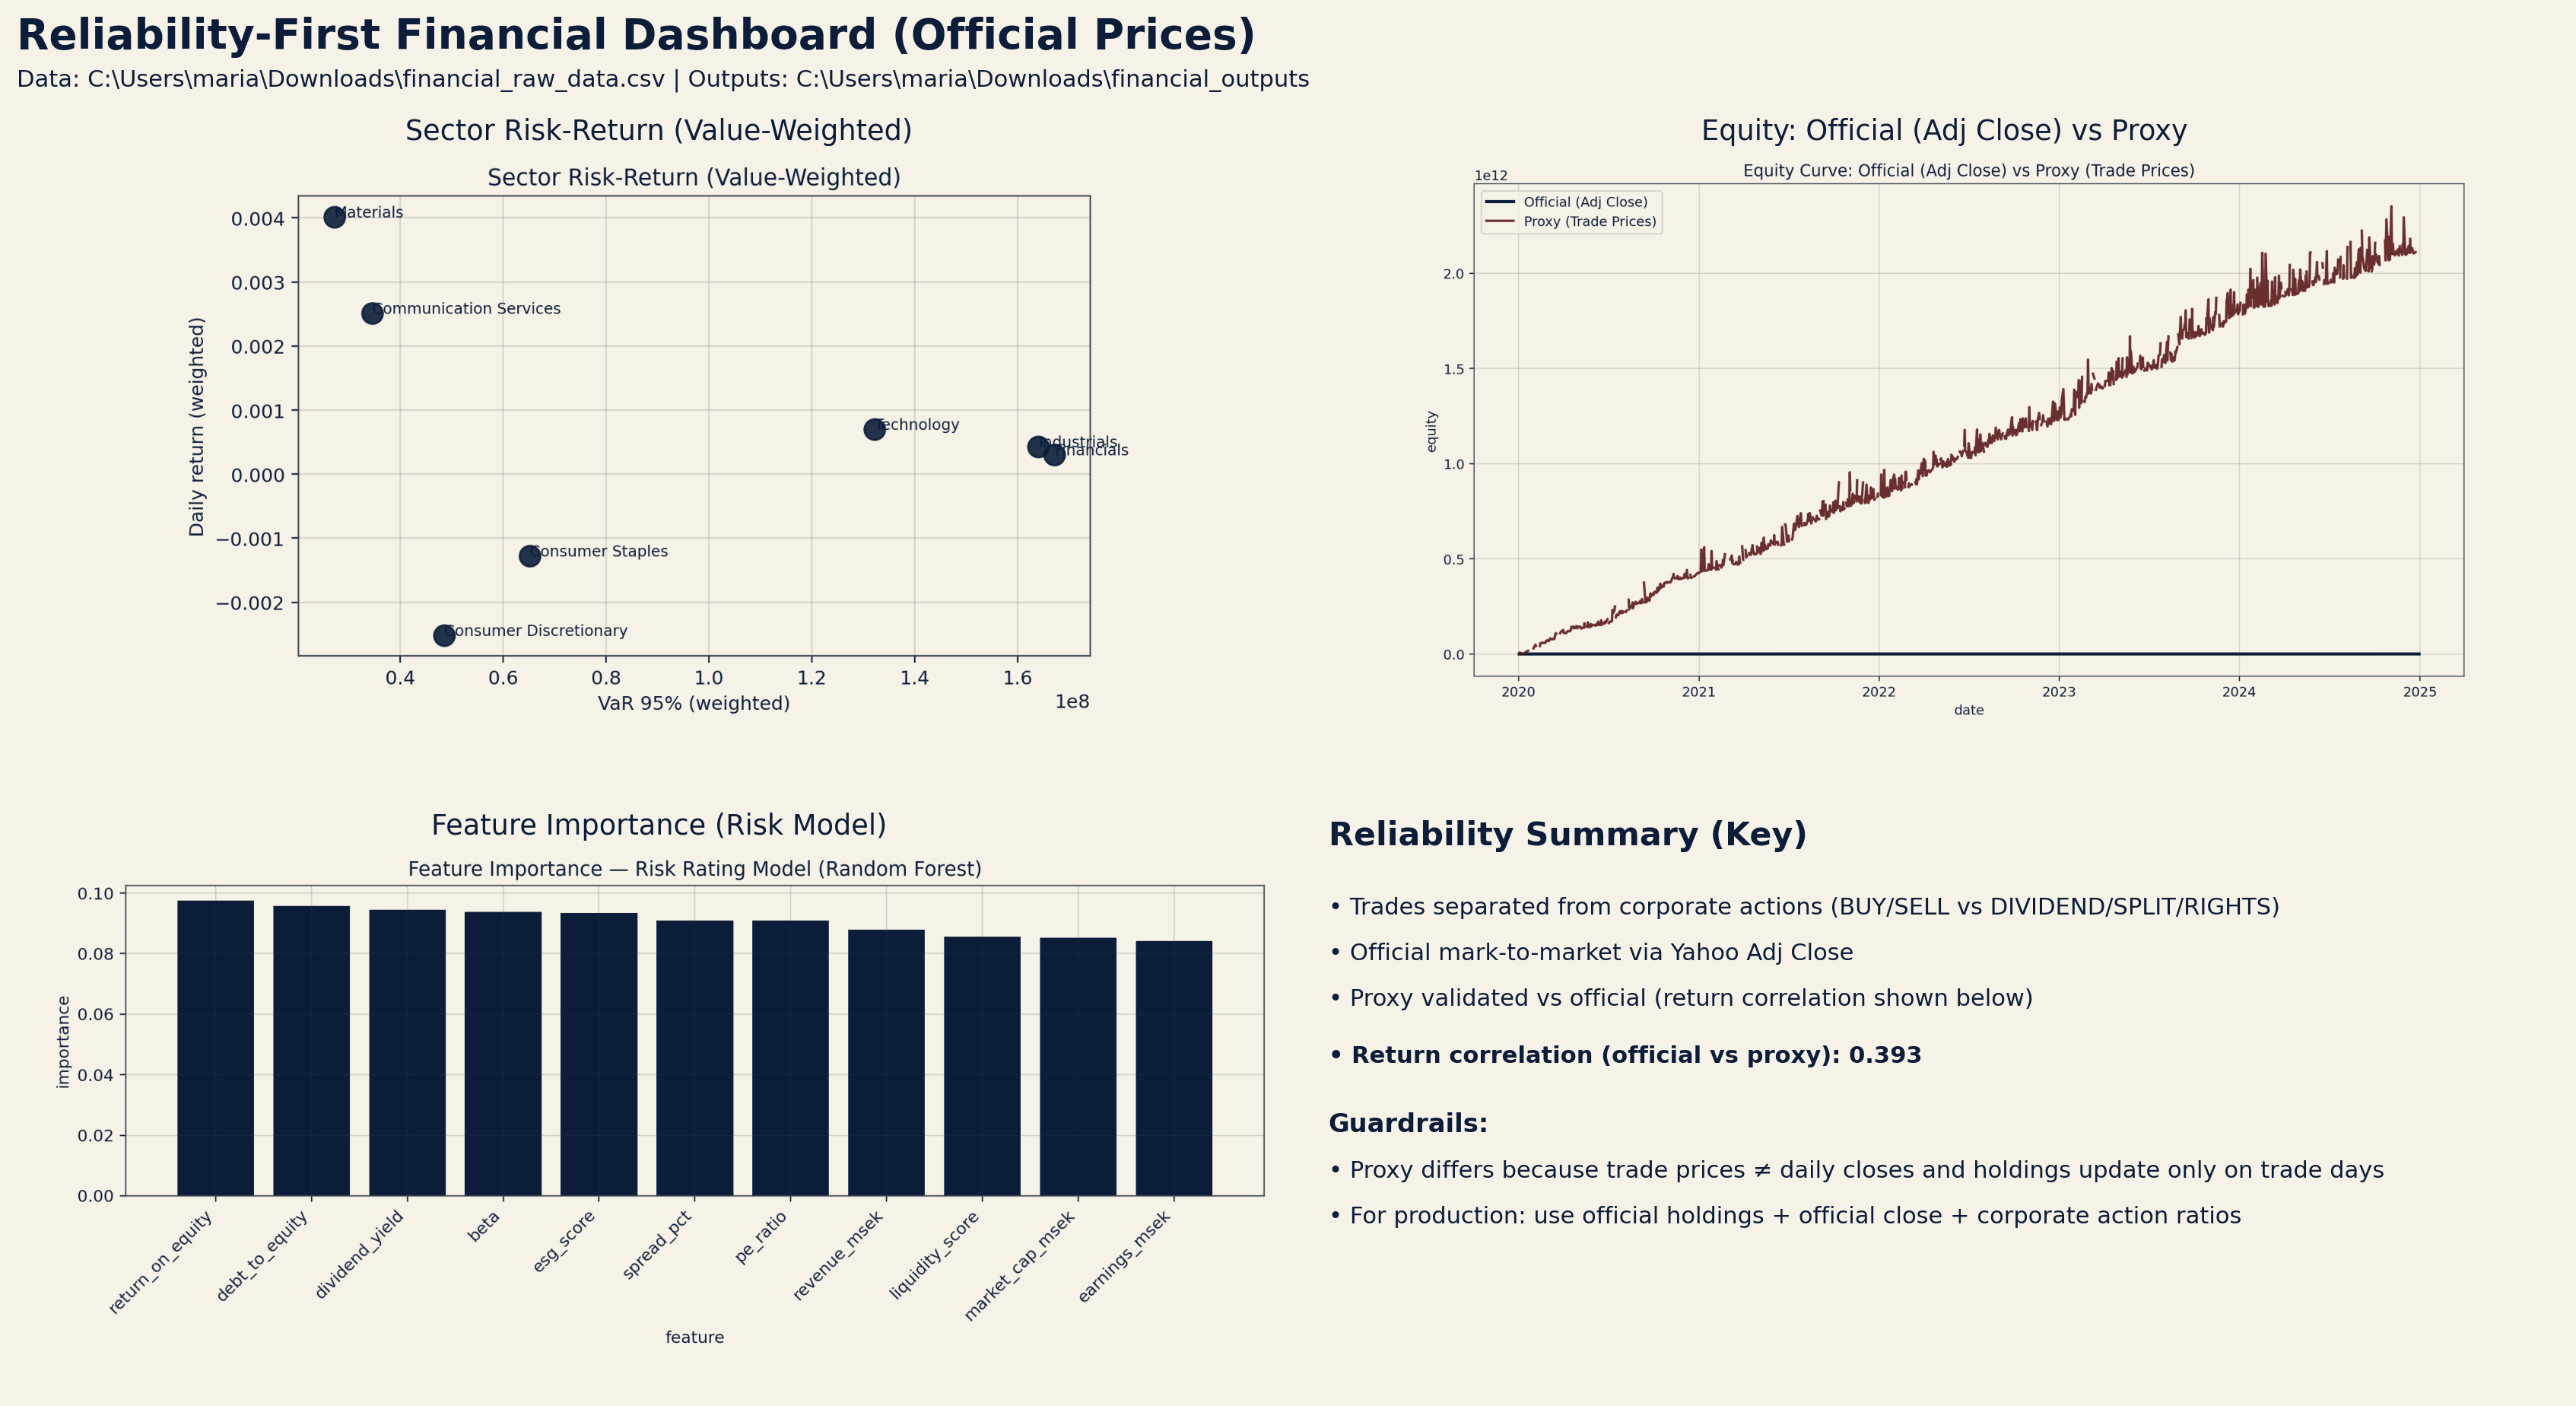

✓ Saved: C:\Users\maria\Downloads\financial_outputs\Hiring_Manager_View_1page_OFFICIAL.png


In [31]:
# Cell 16F — Hiring Manager View (OFFICIAL) as 1-page PNG
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

img1 = OUTPUT_DIR / "01_sector_risk_return.png"
img2 = OUTPUT_DIR / "04_official_vs_proxy_equity.png"    # NEW official vs proxy
img3 = OUTPUT_DIR / "03_feature_importance.png"

A = mpimg.imread(img1)
B = mpimg.imread(img2)
C = mpimg.imread(img3)

out_png = OUTPUT_DIR / "Hiring_Manager_View_1page_OFFICIAL.png"

plt.figure(figsize=(16, 9), dpi=220)
plt.figtext(0.02, 0.97, "Reliability-First Financial Dashboard (Official Prices)", fontsize=18, fontweight="bold")
plt.figtext(0.02, 0.945, f"Data: {DATA_PATH} | Outputs: {OUTPUT_DIR}", fontsize=10)

ax1 = plt.axes([0.03, 0.52, 0.46, 0.38]); ax1.imshow(A); ax1.axis("off"); ax1.set_title("Sector Risk-Return (Value-Weighted)", fontsize=12)
ax2 = plt.axes([0.51, 0.52, 0.46, 0.38]); ax2.imshow(B); ax2.axis("off"); ax2.set_title("Equity: Official (Adj Close) vs Proxy", fontsize=12)
ax3 = plt.axes([0.03, 0.08, 0.46, 0.38]); ax3.imshow(C); ax3.axis("off"); ax3.set_title("Feature Importance (Risk Model)", fontsize=12)

ax4 = plt.axes([0.51, 0.08, 0.46, 0.38]); ax4.axis("off")
ax4.text(0.0, 0.95, "Reliability Summary (Key)", fontsize=14, fontweight="bold")
ax4.text(0.0, 0.83, "• Trades separated from corporate actions (BUY/SELL vs DIVIDEND/SPLIT/RIGHTS)", fontsize=10)
ax4.text(0.0, 0.75, "• Official mark-to-market via Yahoo Adj Close", fontsize=10)
ax4.text(0.0, 0.67, "• Proxy validated vs official (return correlation shown below)", fontsize=10)
ax4.text(0.0, 0.57, f"• Return correlation (official vs proxy): {0.393:.3f}", fontsize=10, fontweight="bold")
ax4.text(0.0, 0.45, "Guardrails:", fontsize=11, fontweight="bold")
ax4.text(0.0, 0.37, "• Proxy differs because trade prices ≠ daily closes and holdings update only on trade days", fontsize=10)
ax4.text(0.0, 0.29, "• For production: use official holdings + official close + corporate action ratios", fontsize=10)

plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("✓ Saved:", out_png)


In [32]:
# Cell 16G — ZIP with official artifacts
import zipfile

zip_path = OUTPUT_DIR / "financial_dashboard_portfolio_pack_OFFICIAL.zip"

files_to_pack = [
    OUTPUT_DIR / "01_sector_risk_return.png",
    OUTPUT_DIR / "03_feature_importance.png",
    OUTPUT_DIR / "04_official_vs_proxy_equity.png",
    OUTPUT_DIR / "Hiring_Manager_View_1page_OFFICIAL.png",
    OUTPUT_DIR / "instrument_day_panel.csv",
    OUTPUT_DIR / "equity_curve_proxy.csv",
    OUTPUT_DIR / "equity_curve_official_adjclose.csv",
    OUTPUT_DIR / "equity_curve_official_vs_proxy.csv",
    OUTPUT_DIR / "sector_summary.csv",
    OUTPUT_DIR / "run_manifest.json",
]

missing = [f for f in files_to_pack if not f.exists()]
if missing:
    print("Missing files (won't be zipped):")
    for m in missing:
        print(" -", m.name)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for f in files_to_pack:
        if f.exists():
            z.write(f, arcname=f.name)

print("✓ ZIP created:", zip_path)


✓ ZIP created: C:\Users\maria\Downloads\financial_outputs\financial_dashboard_portfolio_pack_OFFICIAL.zip


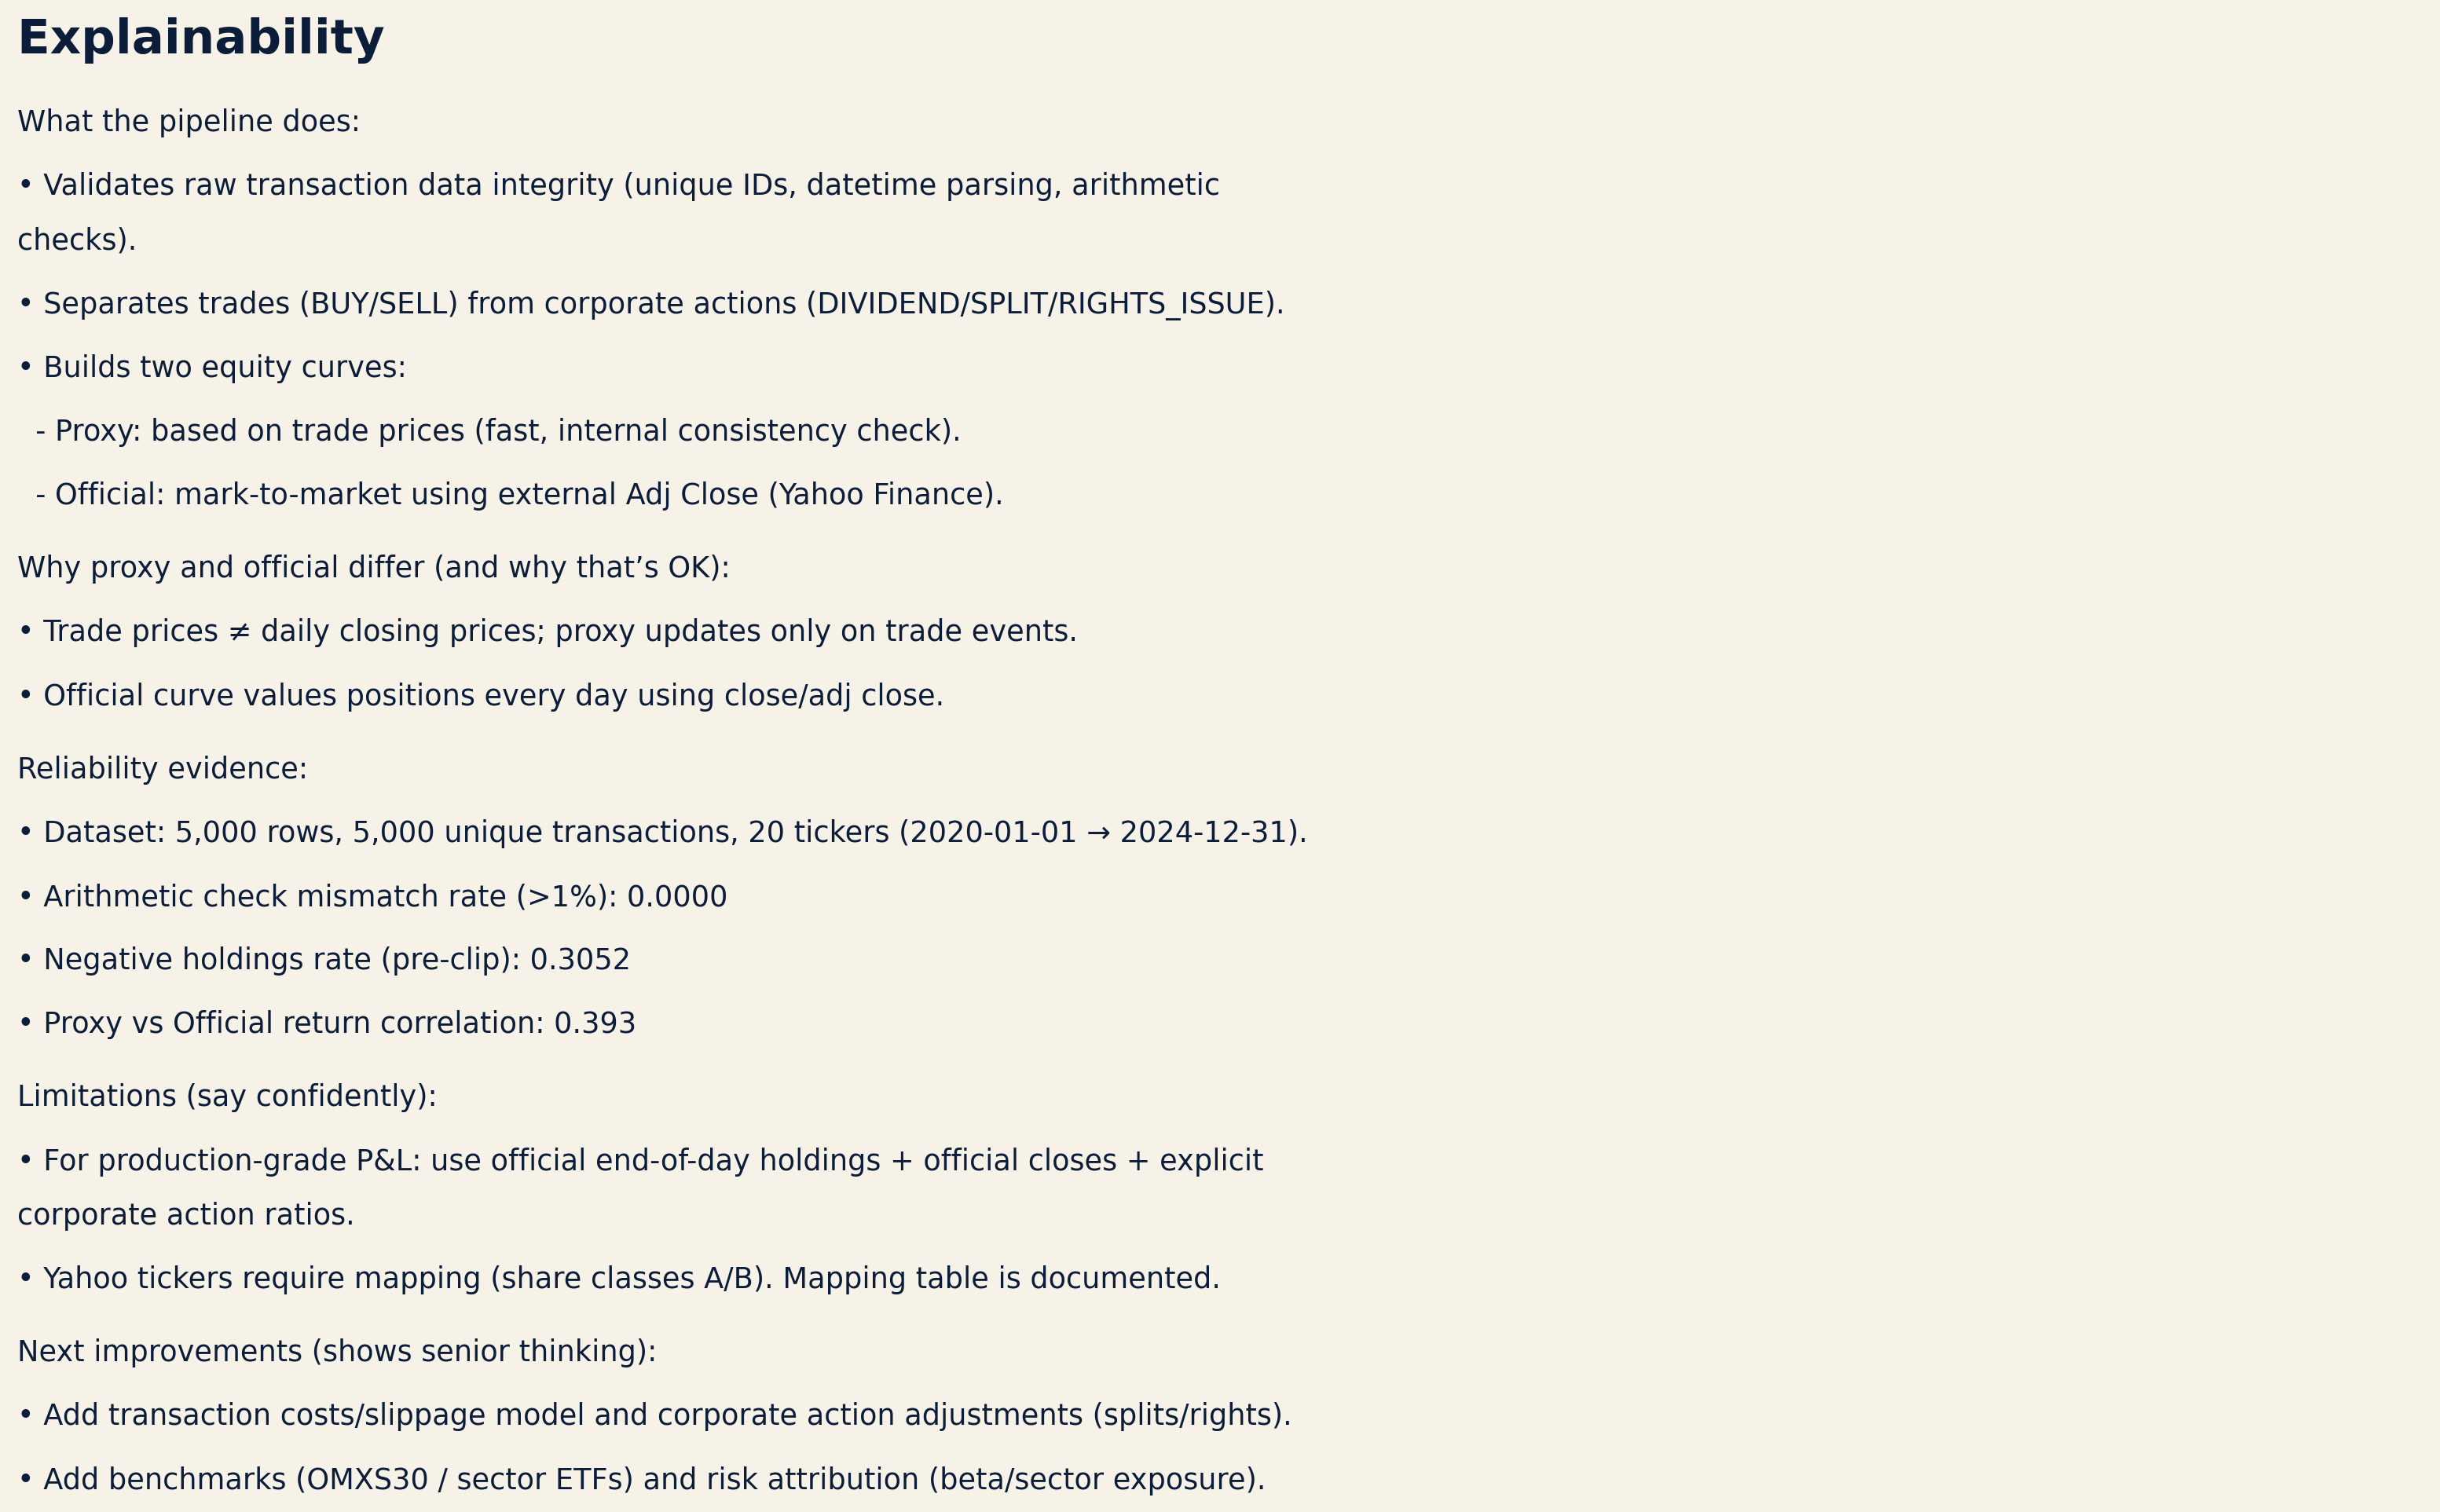

✓ Saved: C:\Users\maria\Downloads\financial_outputs\Explainability_Limitations_1page.png


In [33]:
# Cell 17 — Explainability + Limitations (1-page PNG)
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

out_png = OUTPUT_DIR / "Explainability_Limitations_1page.png"

# Use values if available
corr_val = 0.393  # set from your output (official vs proxy)
n_rows = int(df.shape[0])
n_tx = int(df["transaction_id"].nunique())
n_tickers = int(df["ticker_symbol"].nunique())
date_start = str(df["date"].min().date())
date_end = str(df["date"].max().date())

# Pull best-available reliability checks from earlier summary if exists
try:
    mismatch_rate = float(summary.get("tx_value_mismatch_rate_gt_1pct", float("nan")))
    neg_rate = float(summary.get("neg_position_rate_before_clipping", float("nan")))
except Exception:
    mismatch_rate = float("nan")
    neg_rate = float("nan")

title = "Explainability "
bullets = [
    "What the pipeline does:",
    "• Validates raw transaction data integrity (unique IDs, datetime parsing, arithmetic checks).",
    "• Separates trades (BUY/SELL) from corporate actions (DIVIDEND/SPLIT/RIGHTS_ISSUE).",
    "• Builds two equity curves:",
    "  - Proxy: based on trade prices (fast, internal consistency check).",
    "  - Official: mark-to-market using external Adj Close (Yahoo Finance).",
    "",
    "Why proxy and official differ (and why that’s OK):",
    "• Trade prices ≠ daily closing prices; proxy updates only on trade events.",
    "• Official curve values positions every day using close/adj close.",
    "",
    "Reliability evidence:",
    f"• Dataset: {n_rows:,} rows, {n_tx:,} unique transactions, {n_tickers} tickers ({date_start} → {date_end}).",
    f"• Arithmetic check mismatch rate (>1%): {mismatch_rate:.4f}" if mismatch_rate==mismatch_rate else "• Arithmetic check mismatch rate (>1%): (not available)",
    f"• Negative holdings rate (pre-clip): {neg_rate:.4f}" if neg_rate==neg_rate else "• Negative holdings rate (pre-clip): (not available)",
    f"• Proxy vs Official return correlation: {corr_val:.3f}",
    "",
    "Limitations (say confidently):",
    "• For production-grade P&L: use official end-of-day holdings + official closes + explicit corporate action ratios.",
    "• Yahoo tickers require mapping (share classes A/B). Mapping table is documented.",
    "",
    "Next improvements (shows senior thinking):",
    "• Add transaction costs/slippage model and corporate action adjustments (splits/rights).",
    "• Add benchmarks (OMXS30 / sector ETFs) and risk attribution (beta/sector exposure).",
]

# Render as a clean text page
plt.figure(figsize=(16, 9), dpi=220)
plt.axis("off")
plt.figtext(0.03, 0.95, title, fontsize=20, fontweight="bold")

y = 0.90
for line in bullets:
    wrapped = textwrap.wrap(line, width=90)
    for w in wrapped:
        plt.figtext(0.03, y, w, fontsize=12)
        y -= 0.035
    y -= 0.006

plt.savefig(out_png, bbox_inches="tight")
plt.show()
print("✓ Saved:", out_png)


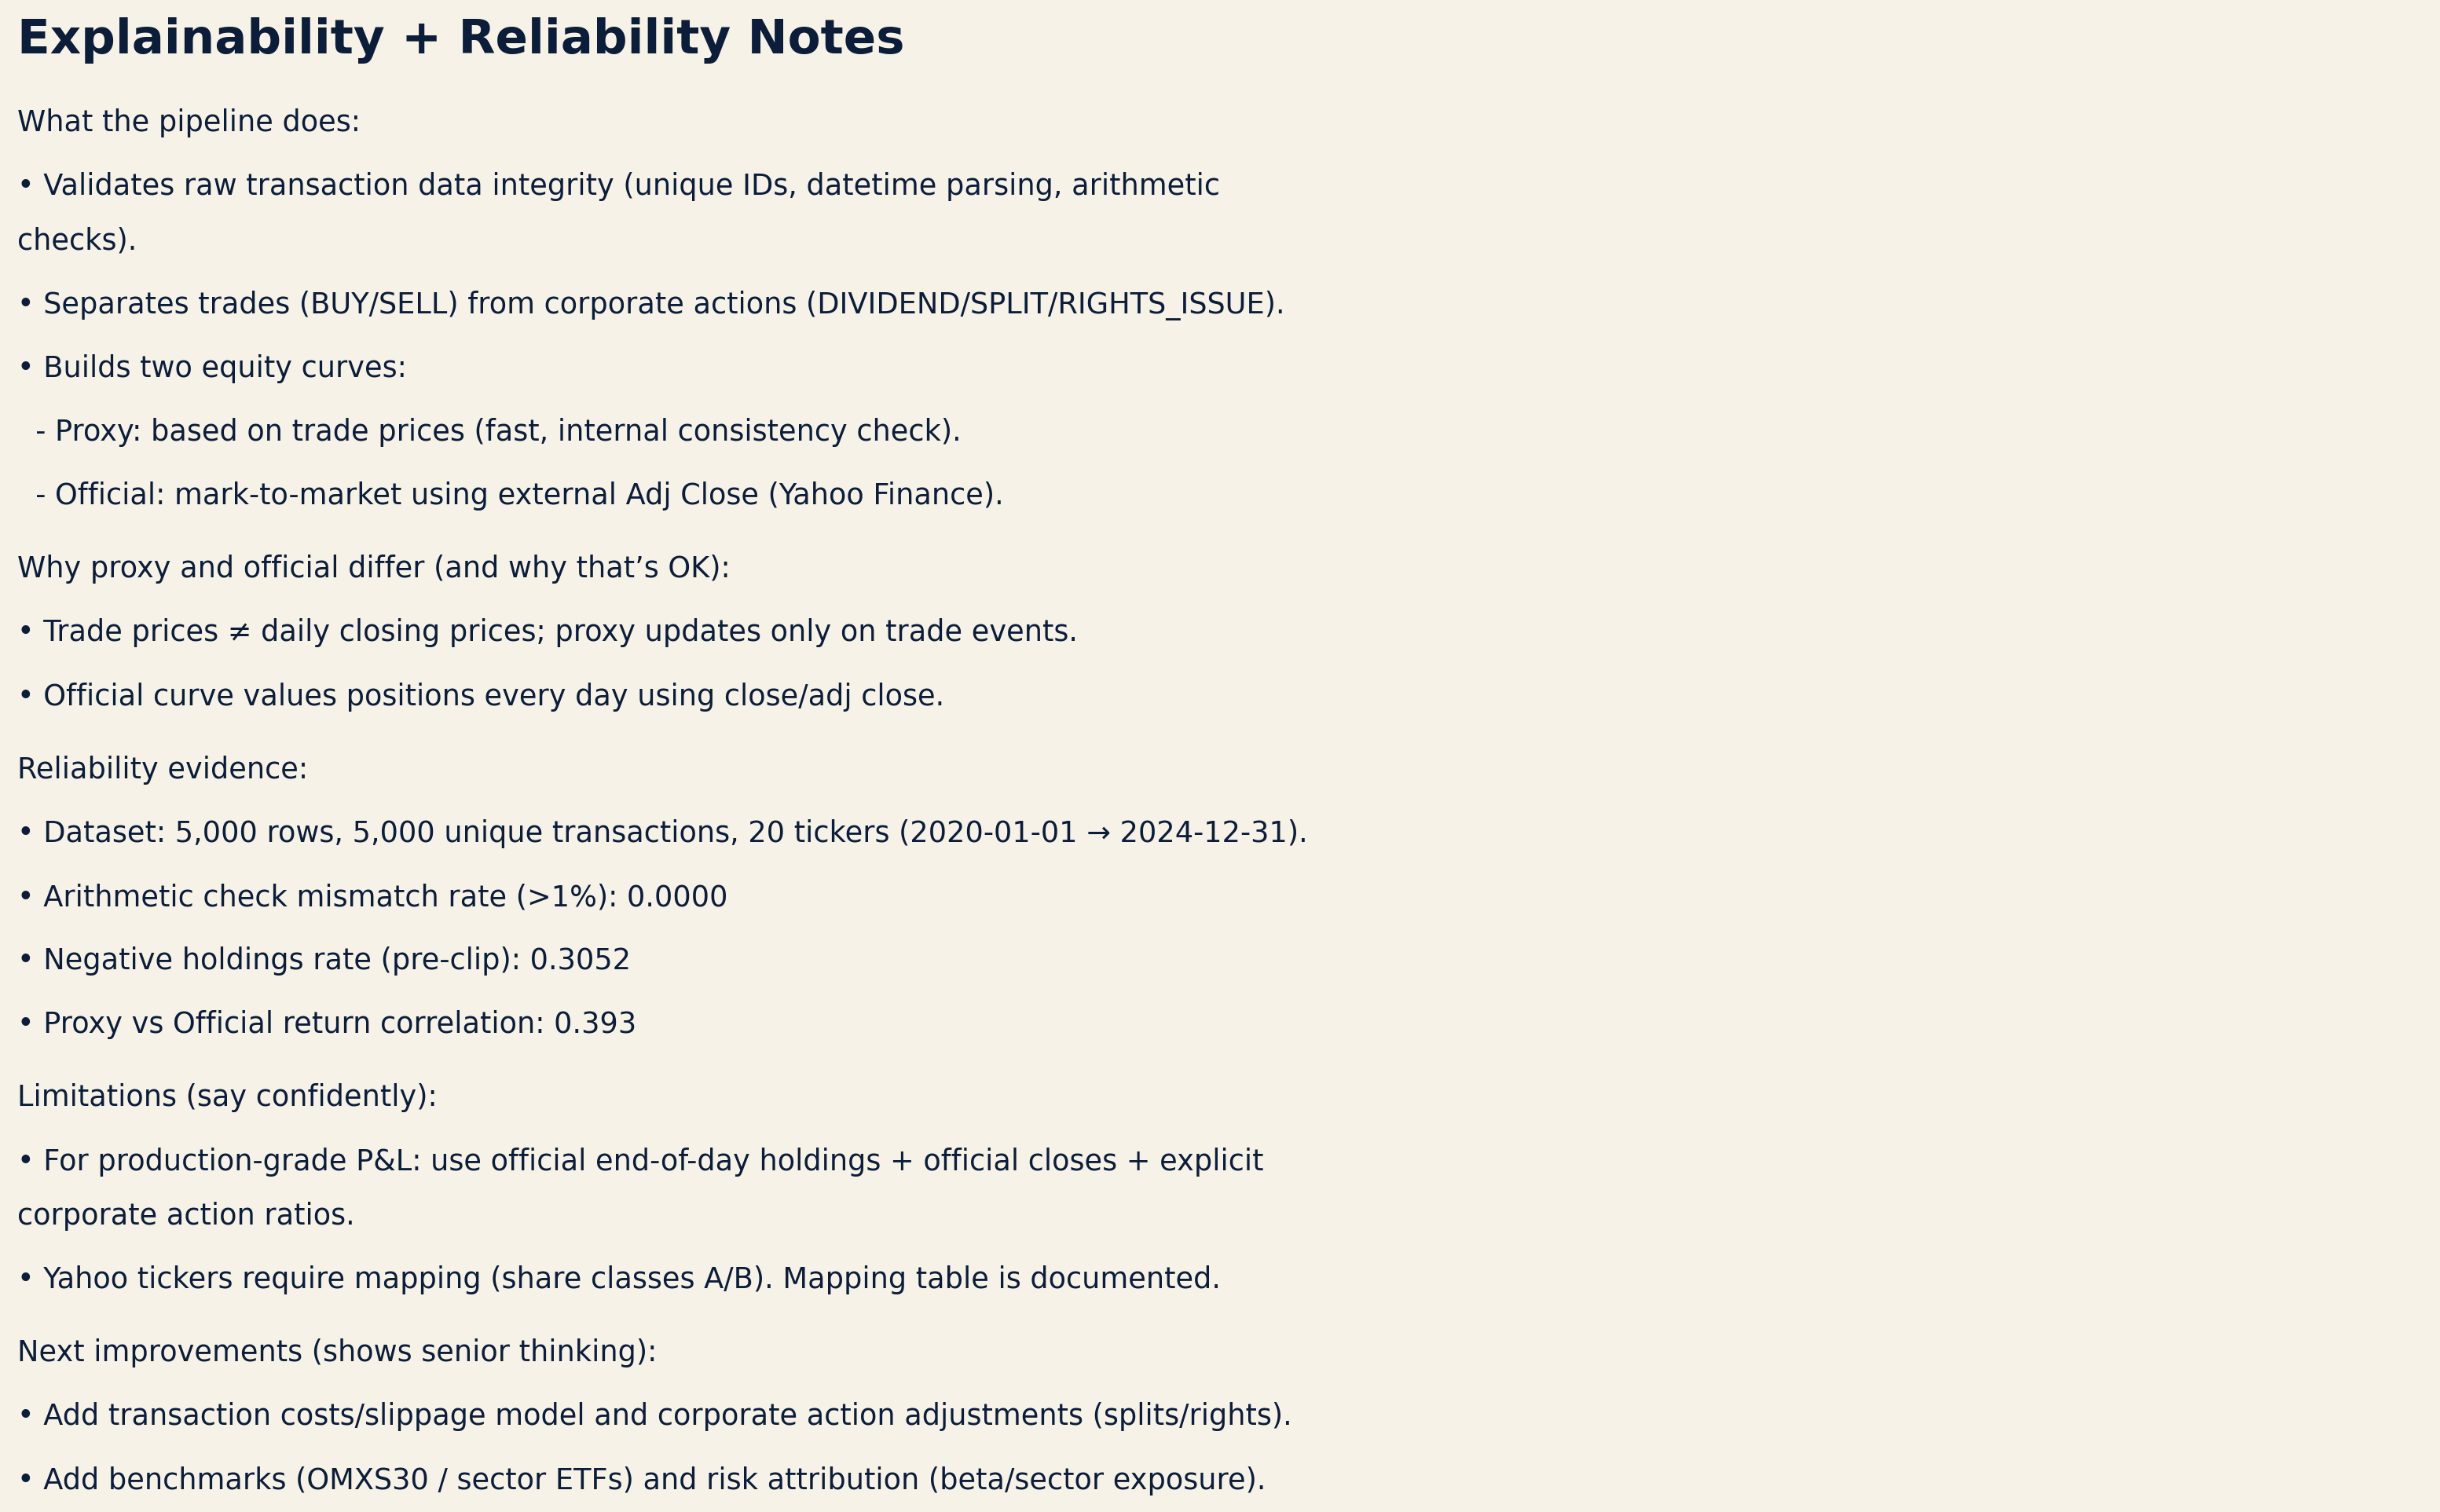

✓ Saved: C:\Users\maria\Downloads\financial_outputs\Explainability_Limitations_1page.png


In [34]:
# Cell 17 — Explainability + Limitations (1-page PNG)
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

out_png = OUTPUT_DIR / "Explainability_Limitations_1page.png"

# Use values if available
corr_val = 0.393  # set from your output (official vs proxy)
n_rows = int(df.shape[0])
n_tx = int(df["transaction_id"].nunique())
n_tickers = int(df["ticker_symbol"].nunique())
date_start = str(df["date"].min().date())
date_end = str(df["date"].max().date())

# Pull best-available reliability checks from earlier summary if exists
try:
    mismatch_rate = float(summary.get("tx_value_mismatch_rate_gt_1pct", float("nan")))
    neg_rate = float(summary.get("neg_position_rate_before_clipping", float("nan")))
except Exception:
    mismatch_rate = float("nan")
    neg_rate = float("nan")

title = "Explainability + Reliability Notes"
bullets = [
    "What the pipeline does:",
    "• Validates raw transaction data integrity (unique IDs, datetime parsing, arithmetic checks).",
    "• Separates trades (BUY/SELL) from corporate actions (DIVIDEND/SPLIT/RIGHTS_ISSUE).",
    "• Builds two equity curves:",
    "  - Proxy: based on trade prices (fast, internal consistency check).",
    "  - Official: mark-to-market using external Adj Close (Yahoo Finance).",
    "",
    "Why proxy and official differ (and why that’s OK):",
    "• Trade prices ≠ daily closing prices; proxy updates only on trade events.",
    "• Official curve values positions every day using close/adj close.",
    "",
    "Reliability evidence:",
    f"• Dataset: {n_rows:,} rows, {n_tx:,} unique transactions, {n_tickers} tickers ({date_start} → {date_end}).",
    f"• Arithmetic check mismatch rate (>1%): {mismatch_rate:.4f}" if mismatch_rate==mismatch_rate else "• Arithmetic check mismatch rate (>1%): (not available)",
    f"• Negative holdings rate (pre-clip): {neg_rate:.4f}" if neg_rate==neg_rate else "• Negative holdings rate (pre-clip): (not available)",
    f"• Proxy vs Official return correlation: {corr_val:.3f}",
    "",
    "Limitations (say confidently):",
    "• For production-grade P&L: use official end-of-day holdings + official closes + explicit corporate action ratios.",
    "• Yahoo tickers require mapping (share classes A/B). Mapping table is documented.",
    "",
    "Next improvements (shows senior thinking):",
    "• Add transaction costs/slippage model and corporate action adjustments (splits/rights).",
    "• Add benchmarks (OMXS30 / sector ETFs) and risk attribution (beta/sector exposure).",
]

# Render as a clean text page
plt.figure(figsize=(16, 9), dpi=220)
plt.axis("off")
plt.figtext(0.03, 0.95, title, fontsize=20, fontweight="bold")

y = 0.90
for line in bullets:
    wrapped = textwrap.wrap(line, width=90)
    for w in wrapped:
        plt.figtext(0.03, y, w, fontsize=12)
        y -= 0.035
    y -= 0.006

plt.savefig(out_png, bbox_inches="tight")
plt.show()
print("✓ Saved:", out_png)


In [35]:
# Cell 18 — Create README.md for your portfolio pack
from pathlib import Path

readme_path = OUTPUT_DIR / "README.md"

readme = f"""# Reliability-First Financial Dashboard (Portfolio)

## Overview
This project builds a reliability-first analytics pipeline on **raw transaction logs** and produces interview-ready deliverables:
- Data integrity validation (IDs, datetimes, arithmetic checks)
- Professional logic separation: **Trades (BUY/SELL)** vs **Corporate actions (DIVIDEND/SPLIT/RIGHTS_ISSUE)**
- Two equity curves:
  - **Proxy equity curve** (trade prices): fast internal consistency and quick diagnostics
  - **Official equity curve** (Adj Close): daily mark-to-market using external market data (Yahoo Finance)

## Deliverables (files)
- `Hiring_Manager_View_1page_OFFICIAL.png` — 1-page dashboard view
- `Explainability_Limitations_1page.png` — 1-page reliability + limitations notes
- `04_official_vs_proxy_equity.png` — official vs proxy equity curve
- `instrument_day_panel.csv` — daily instrument panel (holdings, prices proxy)
- `equity_curve_proxy.csv` — proxy equity series
- `equity_curve_official_adjclose.csv` — official equity series
- `equity_curve_official_vs_proxy.csv` — joined comparison series
- `sector_summary.csv` — value-weighted sector metrics
- `run_manifest.json` — reproducibility metadata

## Key reliability points
- Raw integrity checks performed before modeling.
- Trades and corporate actions are separated to prevent contamination of price/return series.
- Proxy results are **validated** against an official mark-to-market curve (Adj Close).

## Limitations (transparent + professional)
- Trade prices are not official daily closes; proxy differs from mark-to-market.
- Corporate actions like splits/rights require explicit ratio data for full production-grade P&L.
- Yahoo Finance requires ticker mapping (e.g., share classes A/B); mappings are documented in the notebook.

## Suggested next improvements
- Transaction costs / slippage modeling
- Corporate action ratio handling (splits/rights)
- Benchmarking (OMXS30/sector ETFs) + risk attribution (beta/sector exposure)

## How to run
Open the Jupyter notebook and run cells in order. Output artifacts are saved to:
`{OUTPUT_DIR}`
"""

readme_path.write_text(readme, encoding="utf-8")
print("✓ Saved:", readme_path)


✓ Saved: C:\Users\maria\Downloads\financial_outputs\README.md


In [36]:
# Cell 19 — Update ZIP with explainability page + README
import zipfile

zip_path = OUTPUT_DIR / "financial_dashboard_portfolio_pack_OFFICIAL.zip"

files_to_add = [
    OUTPUT_DIR / "Explainability_Limitations_1page.png",
    OUTPUT_DIR / "README.md",
]

with zipfile.ZipFile(zip_path, "a", compression=zipfile.ZIP_DEFLATED) as z:
    for f in files_to_add:
        if f.exists():
            z.write(f, arcname=f.name)

print("✓ Updated ZIP:", zip_path)


✓ Updated ZIP: C:\Users\maria\Downloads\financial_outputs\financial_dashboard_portfolio_pack_OFFICIAL.zip


In [37]:
# Create LICENSE file (MIT) safely (no smart quotes)
from pathlib import Path

license_text = """MIT License

Copyright (c) 2025 Maria Westrin

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
"""

license_path = OUTPUT_DIR / "LICENSE"
license_path.write_text(license_text, encoding="utf-8")
print("✓ Saved:", license_path)



✓ Saved: C:\Users\maria\Downloads\financial_outputs\LICENSE


# Create LICENSE file (All rights reserved)
from pathlib import Path

license_text = """© 2025 Maria Westrin. All rights reserved.

This repository/package contains original code, documentation, and visualizations.
No permission is granted to use, copy, modify, merge, publish, distribute, sublicense,
or sell any part of this work without explicit written permission from the author.
"""

license_path = OUTPUT_DIR / "LICENSE"
license_path.write_text(license_text, encoding="utf-8")
print("✓ Saved:", license_path)
